# Интерпретация

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import partial_dependence, PartialDependenceDisplay, permutation_importance
from sklearn.metrics import mean_squared_error, r2_score
import lime
import lime.lime_tabular

warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'


### Загрузка и подготовка данных


Вам будет предоставлен датасет, посвященный продаже недвижимости. Ваша задача - построить интерпретацию для этого датасета. В нем достаточно много различных признаков, поэтому вы можете предварительно отфильтровать их, когда будете строить графики. Оставляйте достаточно признаков, чтобы ваши модели оставались точными..

In [2]:
data_path = r'C:\go\Projects\spbu_ml_2026\data\data.csv'
data = pd.read_csv(data_path, sep=',')

print(f"Размер датасета: {data.shape}")
print(f"\nПервые строки:")
data.head()


Размер датасета: (29905, 83)

Первые строки:


,region_name_cat,district_cat,corpus_cat,developer_cat,agreement_date,floor,square,rooms_4,location_logs_count_mean,location_depth,...,location_public_transport_platform_w_mean_distance,location_water_w_mean_distance,location_university_w_mean_distance,location_leisure_w_mean_distance,location_pop_shop_cnt,price_target,hc_name_cat,interior_cat,class_cat,stage_cat
0,Город,45,538,18,2012-08-10,3.0,62.23,2,22.550466,13.0,...,0.910028,0.782675,-999.000000,0.820073,16.0,28417.424671,50,49786.0,27353,7983
1,Пригород,48,432,63,2013-05-19,11.0,22.52,студия,22.581858,13.0,...,0.902510,0.902673,-999.000000,0.990908,18.0,16728.215463,293,49786.0,97865,70661
2,Город,44,2372,126,2012-12-12,3.0,38.17,1,20.191250,13.0,...,0.851637,-999.000000,-999.000000,0.945618,7.0,18311.834458,284,49786.0,97865,70661
3,Город,14,1053,121,2012-12-10,10.0,57.48,2,23.286900,13.0,...,0.913797,1.028386,0.300026,0.828147,5.0,25171.489968,325,0.0,97865,12638
4,Город,63,2426,69,2012-02-12,3.0,41.43,1,20.599150,13.0,...,1.051049,-999.000000,-999.000000,0.991506,4.0,27324.795343,182,49786.0,97865,70661


In [3]:
# 1. Преобразование даты
data['agreement_date'] = pd.to_datetime(data['agreement_date'])
data['year'] = data['agreement_date'].dt.year
data['month'] = data['agreement_date'].dt.month
data = data.drop('agreement_date', axis=1)

# 2. rooms_4 (студия → 0, >=4 → 4)
data['rooms_4'] = data['rooms_4'].replace({'студия': 0, '>=4': 4}).astype(float)

# 3. Оставшиеся атегориальные признаки → OneHot
cat_cols = ['region_name_cat']
data = pd.get_dummies(data, columns=cat_cols, drop_first=True)

# Замена -999 на NaN + простая импутация медианой
data = data.replace(-999, np.nan)
data = data.fillna(data.median(numeric_only=True))

X = data.drop('price_target', axis=1)
y = data['price_target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Размер train:", X_train.shape)

Размер train: (23924, 84)


## Задание 1. 1 балл
Сделайте 2 версии данных - с нормализацией признаков и без.
Обучите 6 моделей:
- линейную регрессию (LinearRegression) на двух вариантах данных
- Lasso регрессию (Lasso) на двух вариантах данных
- градиентный бустинг (GradientBoostingRegressor) на двух вариантах данных. Ограничьте глубину до 5.

Выведите MSE,RMSE и MAPE моделей. Какая функция больше подходит? Почему?

Зафиксируйте выводы. Какие модели чувствительны к масштабу признаков, а какие почти инвариантны? Почему это важно для анализа признаков?

### Версия без нормализации (raw)

In [4]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error

models_raw = {
    'LR_raw': LinearRegression(),
    'Lasso_raw': Lasso(alpha=0.1, max_iter=10000),
    'GB_raw': GradientBoostingRegressor(max_depth=5, random_state=42, n_estimators=100)
}

results_raw = {}
for name, model in models_raw.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    mape = mean_absolute_percentage_error(y_test, pred) * 100
    results_raw[name] = {'MSE': mse, 'RMSE': rmse, 'MAPE': mape}
    print(f"{name}: MSE={mse:,.0f} | RMSE={rmse:,.0f} | MAPE={mape:.2f}%")

LR_raw: MSE=23,021,507 | RMSE=4,798 | MAPE=11.55%
Lasso_raw: MSE=23,245,283 | RMSE=4,821 | MAPE=11.71%
GB_raw: MSE=3,532,631 | RMSE=1,880 | MAPE=4.03%


### Версия с нормализацией (StandardScaler)


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models_scaled = {
    'LR_scaled': LinearRegression(),
    'Lasso_scaled': Lasso(alpha=0.1, max_iter=10000),
    'GB_scaled': GradientBoostingRegressor(max_depth=5, random_state=42, n_estimators=100)
}

results_scaled = {}
for name, model in models_scaled.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    mape = mean_absolute_percentage_error(y_test, pred) * 100
    results_scaled[name] = {'MSE': mse, 'RMSE': rmse, 'MAPE': mape}
    print(f"{name}: MSE={mse:,.0f} | RMSE={rmse:,.0f} | MAPE={mape:.2f}%")

LR_scaled: MSE=23,021,507 | RMSE=4,798 | MAPE=11.55%
Lasso_scaled: MSE=23,019,916 | RMSE=4,798 | MAPE=11.55%
GB_scaled: MSE=3,532,601 | RMSE=1,880 | MAPE=4.03%


**Выводы по 1:**

- Лучшая метрика для цены за м² — **MAPE** (относительная ошибка в %). Она интуитивно понятна (ошибка в %), не зависит от масштаба цен и не так сильно наказывает за редкие дорогие объекты, как MSE/RMSE.  
- **LinearRegression** и **Lasso** могут менять качество при нормализации но в данном случае заметных изменений нет.  
- **GradientBoostingRegressor** почти не должен меняется — деревья используют пороги, а не расстояния.  
- Это важно для анализа признаков: в линейных моделях важность по |coef| или Lasso-пенальти без масштабирования — бессмысленно (признак с диапазоном 0–1000 будет "важнее" признака 0–1).  

## Задание 1.1(*) 1 балл
Сравните модели, построенные с помощью разных видов нормализации (MinMax, Standart). Отличается ли важность признаков?

### MinMax версия

In [6]:
from sklearn.preprocessing import MinMaxScaler

scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm = scaler_mm.transform(X_test)

models_mm = {
    'LR_mm': LinearRegression(),
    'Lasso_mm': Lasso(alpha=0.1, max_iter=10000),
    'GB_mm': GradientBoostingRegressor(max_depth=5, random_state=42, n_estimators=100)
}

print("\n=== MinMaxScaler ===")
for name, model in models_mm.items():
    model.fit(X_train_mm, y_train)
    pred = model.predict(X_test_mm)
    mape = mean_absolute_percentage_error(y_test, pred) * 100
    print(f"{name}: MAPE={mape:.2f}%")


=== MinMaxScaler ===
LR_mm: MAPE=11.55%
Lasso_mm: MAPE=11.54%
GB_mm: MAPE=4.03%


In [7]:
lasso_std = Lasso(alpha=0.1).fit(X_train_scaled, y_train)
lasso_mm = Lasso(alpha=0.1).fit(X_train_mm, y_train)

coef_std = pd.Series(np.abs(lasso_std.coef_), index=X.columns)
coef_mm = pd.Series(np.abs(lasso_mm.coef_), index=X.columns)

print("Топ-10 важных по StandardScaler:\n", coef_std.nlargest(10), sep="")
print("\nТоп-10 важных по MinMaxScaler:\n", coef_mm.nlargest(10), sep="")

Топ-10 важных по StandardScaler:
location_public_transport_platform_cnt    3974.499541
class_cat                                 3322.496293
location_std_levels_mean                  3030.131746
location_pop_shop_cnt                     3006.084665
location_max_levels_max                   2740.656025
location_highway_traffic_signals_cnt      2705.864097
location_amenity_bank_w_mean_distance     2682.924167
location_marketplace_w_mean_distance      2464.729686
square                                    2426.686242
location_logs_count_std                   2346.585001
dtype: float64

Топ-10 важных по MinMaxScaler:
square                                    38934.247035
location_motel_cnt                        33226.940417
location_max_levels_max                   23524.503460
location_std_levels_mean                  23123.142687
location_public_transport_platform_cnt    22863.686368
location_railway_station_cnt              18691.506035
location_logs_count_std                   17916.27

**Вывод по 1.1:**

- Порядок топ-признаков **ощутимо поменялся**, плюс немного изменился состав (из десятки выпали class_cat, location_pop_shop_cnt, location_marketplace_w_mean_distance и появились location_motel_cnt, location_railway_station_cnt, location_suburb_cnt).  
- Абсолютные значения коэффициентов **сильно отличаются** (MinMax сжимает всё в [0;1], Standard — в стандартные отклонения).   

## Задание 2. 1 балл
Выберите 1 признак для анализа (можно категориальный, с не менее чем 5 уровнями, или дискретизируйте непрерывный). 
Используйте линейную регрессию и бустинг после применения MinMaxScaler. Что будет с моделями, если признаки выйдут из диапазона?
Постройте графики ICE и PDP для интерпретации исходных данных, а также искусственно добавив несколько выбросов, выходящих за оригинальные интервалы. 


### Выбор признака + подготовка

In [8]:
feature_main = 'floor'
feature_extra = 'stage_cat'

# Находим индексы колонок (потому что модели обучены на numpy-массивах)
col_names = X.columns.tolist()
idx_main = col_names.index(feature_main)
idx_extra = col_names.index(feature_extra)

print(f"Признак для анализа: '{feature_main}' (индекс {idx_main}, уникальных {X_test[feature_main].nunique()})")
print(f"Дополнительный признак: '{feature_extra}' (индекс {idx_extra}, уникальных {X_test[feature_extra].nunique()})")

Признак для анализа: 'floor' (индекс 3, уникальных 42)
Дополнительный признак: 'stage_cat' (индекс 79, уникальных 8)


### PDP + ICE на нормальных данных (MinMaxScaler модели)

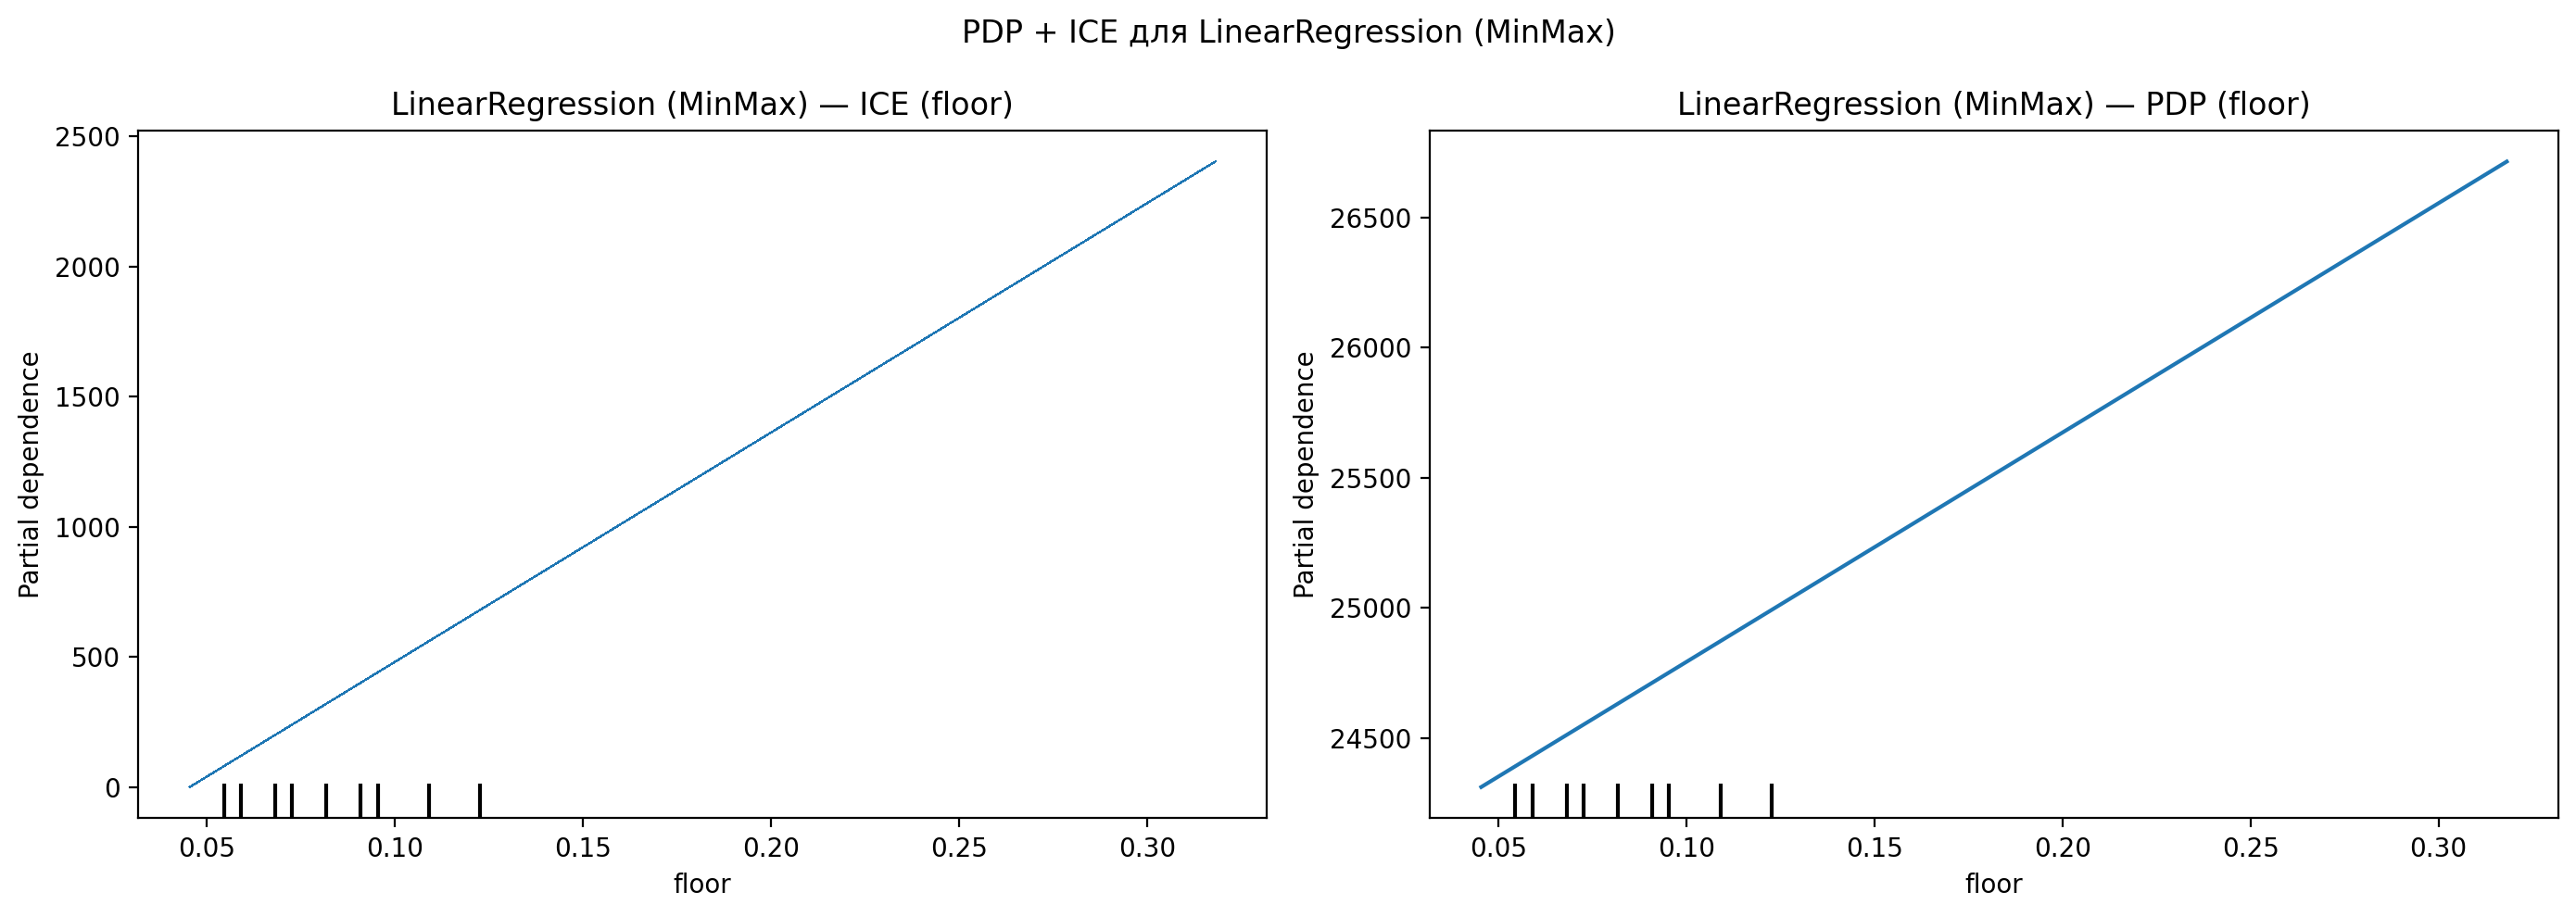

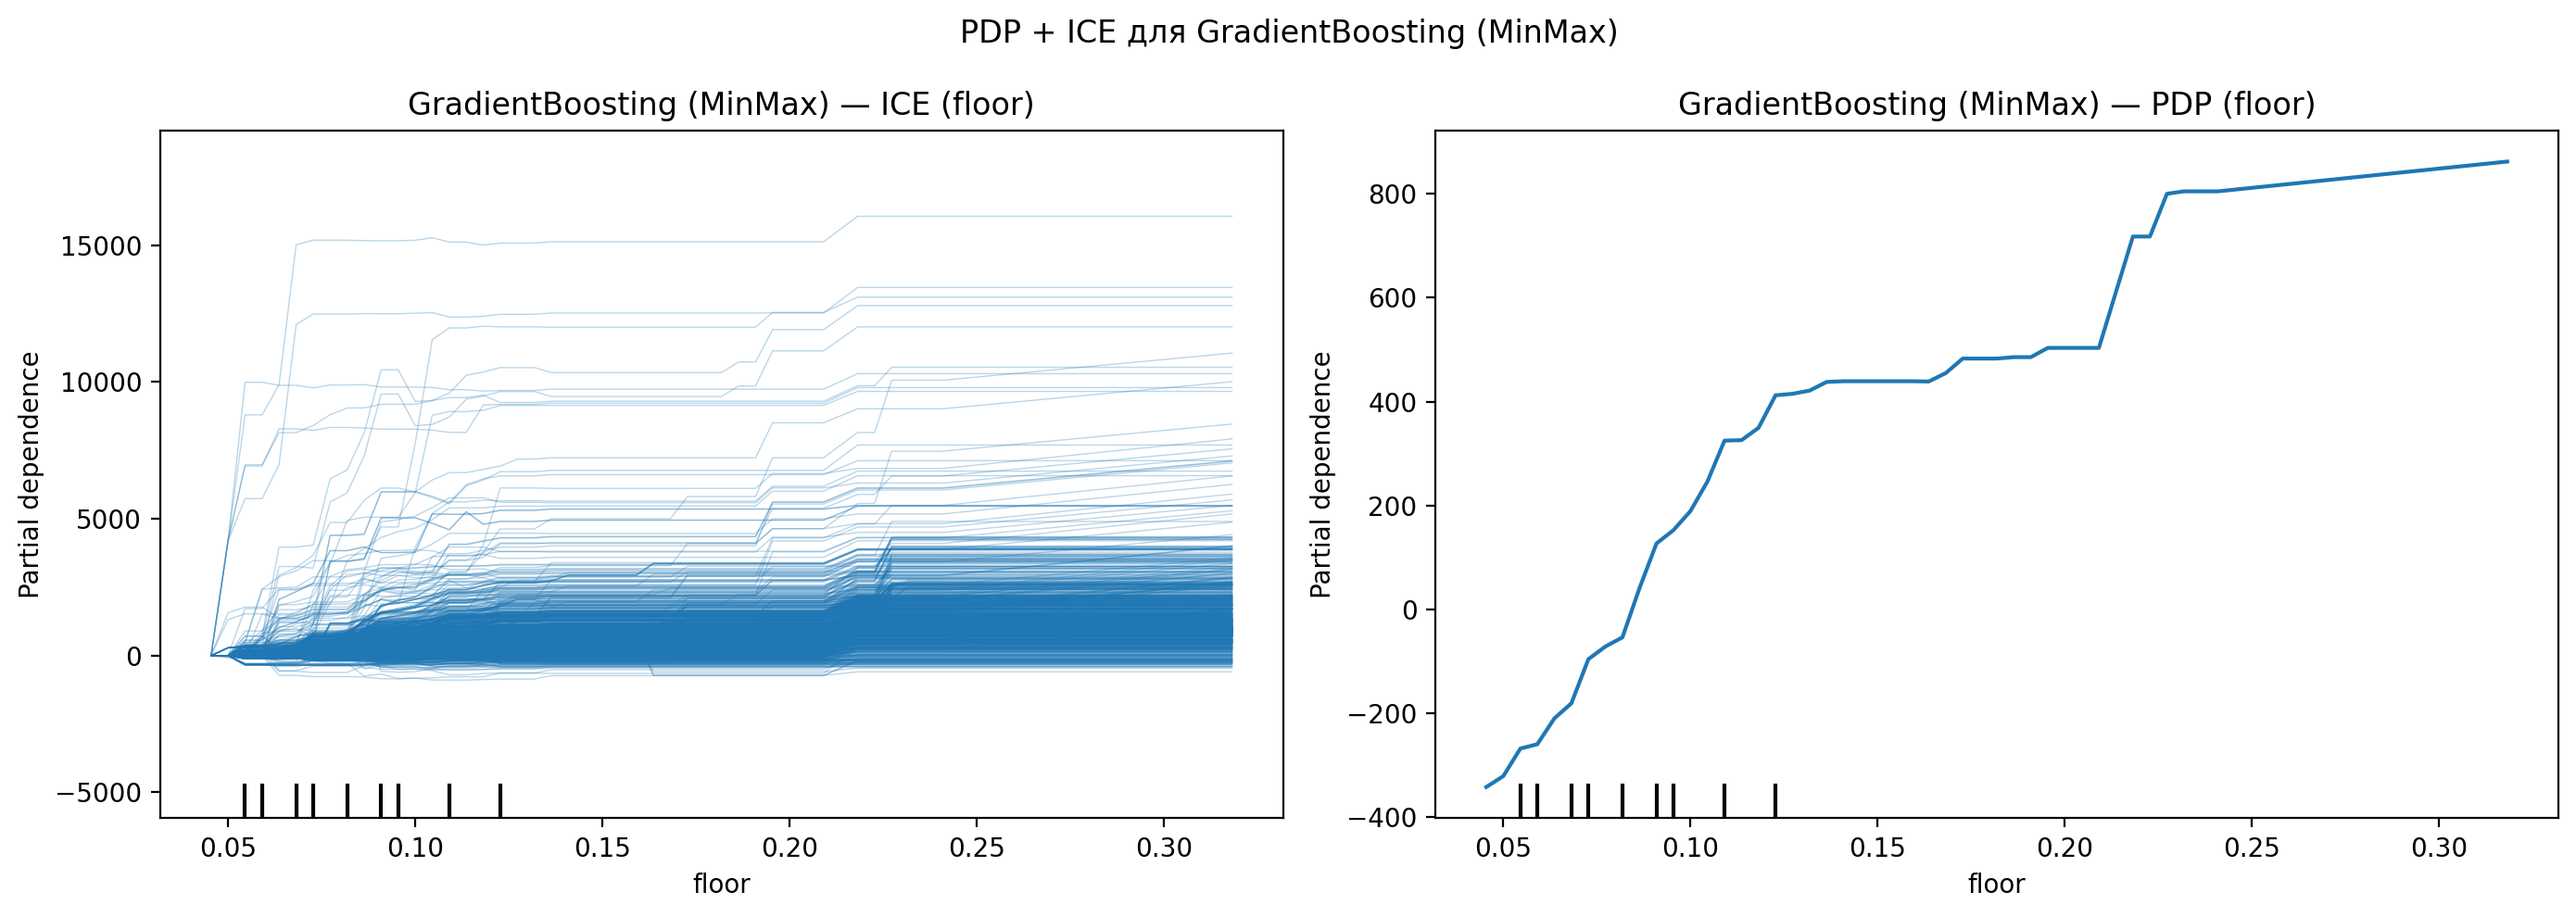

In [9]:
from sklearn.inspection import PartialDependenceDisplay

models_for_pdp = {
    'LinearRegression (MinMax)': models_mm['LR_mm'],
    'GradientBoosting (MinMax)': models_mm['GB_mm']
}

for name, model in models_for_pdp.items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # ICE (индивидуальные кривые, центрированные)
    PartialDependenceDisplay.from_estimator(
        model, X_test_mm, features=[idx_main],
        feature_names=X.columns.tolist(),
        kind="individual",
        centered=True,
        grid_resolution=50,
        percentiles=(0.01, 0.99),
        ax=axes[0]
    )
    axes[0].set_title(f"{name} — ICE ({feature_main})")
    axes[0].set_xlabel(f"{feature_main} (scaled)")
    axes[0].grid(True, alpha=0.3)
    
    # PDP (средняя зависимость)
    PartialDependenceDisplay.from_estimator(
        model, X_test_mm, features=[idx_main],
        feature_names=X.columns.tolist(),
        kind="average",
        grid_resolution=50,
        percentiles=(0.01, 0.99),
        ax=axes[1]
    )
    axes[1].set_title(f"{name} — PDP ({feature_main})")
    axes[1].set_xlabel(f"{feature_main} (scaled)")
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle(f"PDP + ICE для {name}")
    plt.tight_layout()
    plt.show()

### Искусственные выбросы за пределы диапазона [0,1]

In [10]:
X_test_mm_outliers = X_test_mm.copy()

# базовая строка (средние значения признаков)
base_row = X_test_mm.mean(axis=0).copy()

values_to_test = [-0.5, 0.0, 0.15, 0.5, 1.0, 1.5]

new_rows = []

for value in values_to_test:
    new_row = base_row.copy()
    new_row[idx_main] = value
    new_rows.append(new_row)

X_test_mm_outliers = np.vstack([
    X_test_mm_outliers,
    np.array(new_rows)
])

pred_lr = models_mm['LR_mm'].predict(X_test_mm_outliers)
pred_gb = models_mm['GB_mm'].predict(X_test_mm_outliers)

print("=== Экстраполяция признака ===")
for i, value in enumerate(values_to_test):
    print(
        f"{feature_main}_scaled = {value:>4}: "
        f"LR = {pred_lr[-len(values_to_test)+i]:,.0f} руб/м^2 | "
        f"GB = {pred_gb[-len(values_to_test)+i]:,.0f} руб/м^2"
    )

=== Экстраполяция признака ===
floor_scaled = -0.5: LR = 19,504 руб/м^2 | GB = 19,409 руб/м^2
floor_scaled =  0.0: LR = 23,910 руб/м^2 | GB = 19,409 руб/м^2
floor_scaled = 0.15: LR = 25,232 руб/м^2 | GB = 19,891 руб/м^2
floor_scaled =  0.5: LR = 28,316 руб/м^2 | GB = 20,402 руб/м^2
floor_scaled =  1.0: LR = 32,722 руб/м^2 | GB = 20,402 руб/м^2
floor_scaled =  1.5: LR = 37,128 руб/м^2 | GB = 20,402 руб/м^2



Задание 2.1 (*) 1 балл: проанализируйте также еще один признак

### Второй признак

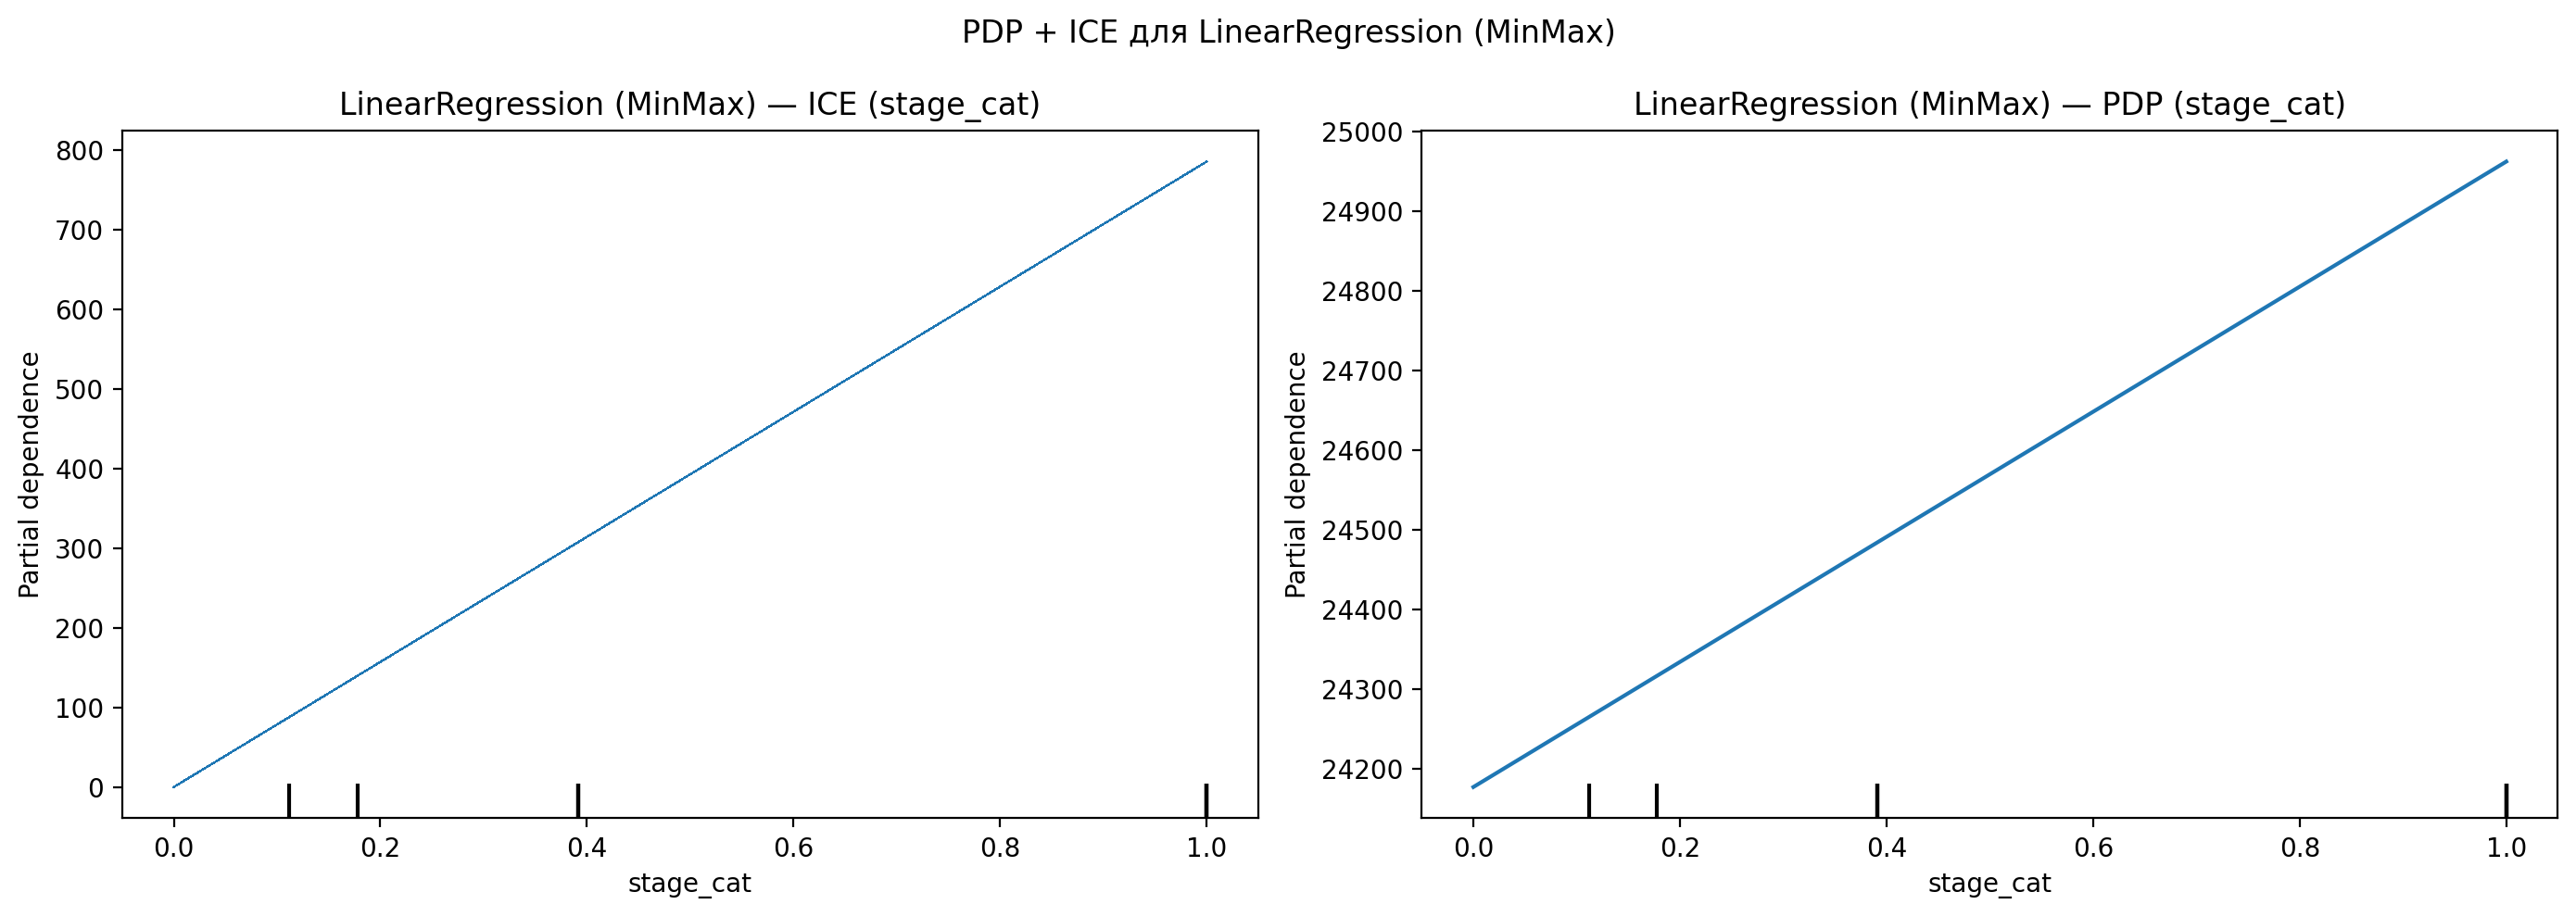

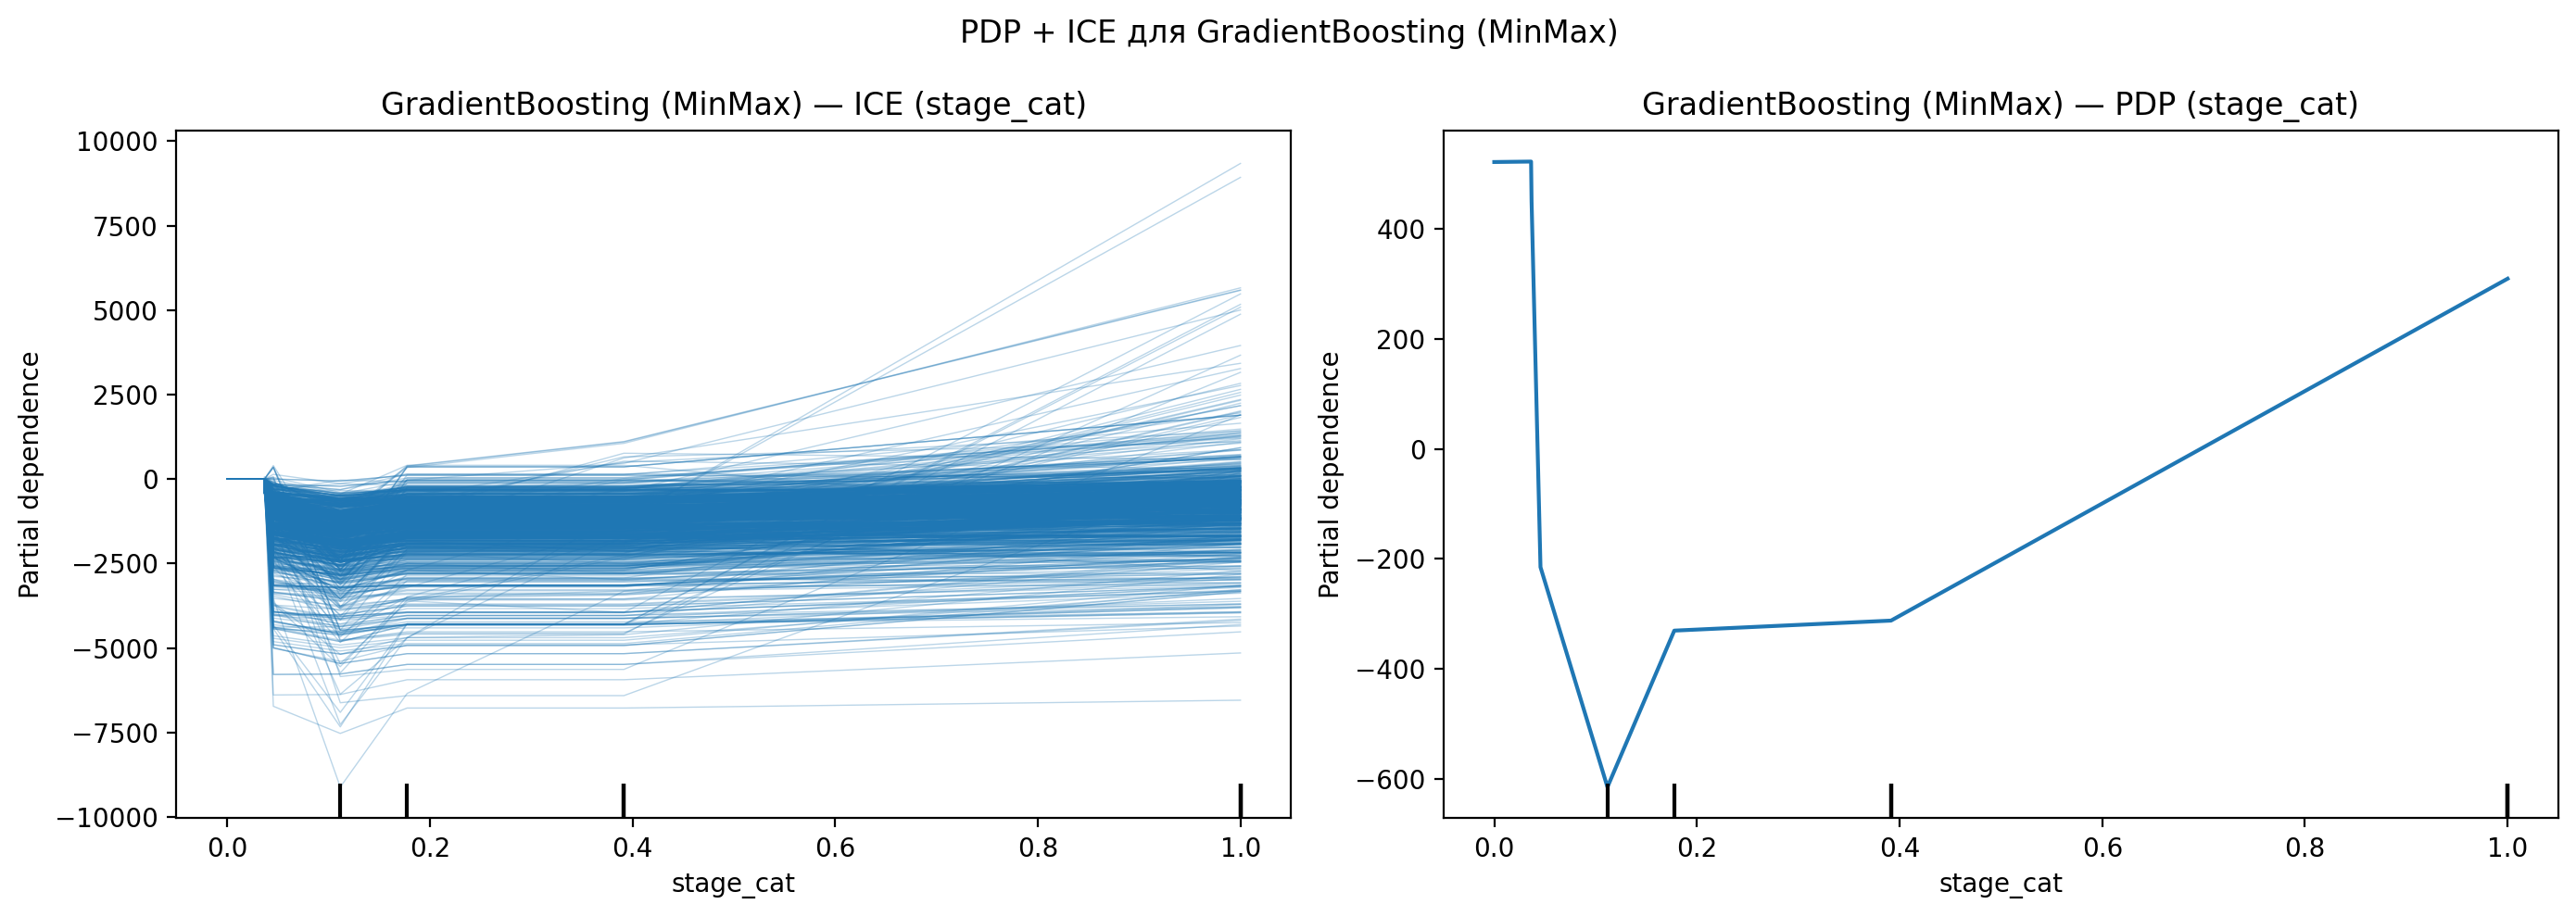

In [11]:
for name, model in models_for_pdp.items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # ICE (индивидуальные кривые, центрированные)
    PartialDependenceDisplay.from_estimator(
        model, X_test_mm, features=[idx_extra],
        feature_names=X.columns.tolist(),
        kind="individual",
        centered=True,
        grid_resolution=50,
        percentiles=(0.01, 0.99),
        ax=axes[0]
    )
    axes[0].set_title(f"{name} — ICE ({feature_extra})")
    axes[0].set_xlabel(f"{feature_extra} (scaled)")
    axes[0].grid(True, alpha=0.3)
    
    # PDP (средняя зависимость)
    PartialDependenceDisplay.from_estimator(
        model, X_test_mm, features=[idx_extra],
        feature_names=X.columns.tolist(),
        kind="average",
        grid_resolution=50,
        percentiles=(0.01, 0.99),
        ax=axes[1]
    )
    axes[1].set_title(f"{name} — PDP ({feature_extra})")
    axes[1].set_xlabel(f"{feature_extra} (scaled)")
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle(f"PDP + ICE для {name}")
    plt.tight_layout()
    plt.show()

In [12]:
X_test_mm_outliers = X_test_mm.copy()

values_to_test = [-0.5, 0.0, 0.15, 0.5, 1.0, 1.5]

new_rows = []

for value in values_to_test:
    new_row = base_row.copy()
    new_row[idx_extra] = value
    new_rows.append(new_row)

X_test_mm_outliers = np.vstack([
    X_test_mm_outliers,
    np.array(new_rows)
])

pred_lr = models_mm['LR_mm'].predict(X_test_mm_outliers)
pred_gb = models_mm['GB_mm'].predict(X_test_mm_outliers)

print("=== Экстраполяция признака ===")
for i, value in enumerate(values_to_test):
    print(
        f"{feature_extra}_scaled = {value:>4}: "
        f"LR = {pred_lr[-len(values_to_test)+i]:,.0f} руб/м^2 | "
        f"GB = {pred_gb[-len(values_to_test)+i]:,.0f} руб/м^2"
    )

=== Экстраполяция признака ===
stage_cat_scaled = -0.5: LR = 23,785 руб/м^2 | GB = 20,557 руб/м^2
stage_cat_scaled =  0.0: LR = 24,177 руб/м^2 | GB = 20,557 руб/м^2
stage_cat_scaled = 0.15: LR = 24,295 руб/м^2 | GB = 19,434 руб/м^2
stage_cat_scaled =  0.5: LR = 24,570 руб/м^2 | GB = 19,434 руб/м^2
stage_cat_scaled =  1.0: LR = 24,963 руб/м^2 | GB = 20,009 руб/м^2
stage_cat_scaled =  1.5: LR = 25,355 руб/м^2 | GB = 20,009 руб/м^2


**Выводы по 2/2.1:**

- **Что происходит, когда признаки выходят за диапазон [0,1] после MinMaxScaler?**  
  - **LinearRegression**: модель **неограниченно экстраполирует**. При `floor_scaled = -0.5` цена падает, при `1.5` — резко растёт. Линейная модель не знает границ и продолжает линию тренда.  
  - **GradientBoosting (деревья)**: модель **стабильна**. Прогнозы почти не меняются при выходе за пределы — деревья просто "застревают" на крайнем листе. Это делает бустинг гораздо безопаснее при неожиданных выбросах.

- **ICE vs PDP**:  
  - У **LinearRegression** все ICE-кривые — идеально параллельные прямые (линейная зависимость). PDP — тоже прямая.  
  - У **GradientBoosting** ICE-кривые имеют ступеньки и изгибы (нелинейность). PDP показывает средний тренд: чем выше этаж — тем выше цена, потом плато.  
  - Для `stage_cat` (категориальный) GB даёт резкое падение в начале, затем подъем, LR — плавный наклон (хотя признак дискретный).

## Задание 3. 1 балл
Выберите 20 объектов из тестовой выборки.
Для каждого объекта из выбранного набора построим траекторию изменения предсказания модели при постепенном изменении значения признака от его текущего значения к базовому значению (медиана или среднее по обучающей выборке).

**Алгоритм:**
1. Выбрать объект $x_i$ из тестовой выборки
2. Для интересующего признака $j$:
   - Текущее значение: $x_{i,j}$
   - Базовое значение: $x_{base,j}$ (медиана или среднее по обучающей выборке)
3. Построить линейную интерполяцию между $x_{i,j}$ и $x_{base,j}$ с $n$ шагами
4. Для каждого шага интерполяции:
   - Заменить значение признака $j$ в объекте $x_i$ на значение из интерполяции
   - Вычислить предсказание модели для модифицированного объекта
5. Построить график траектории

### Траектории изменения предсказания

In [13]:
def prediction_change(feature_j = 'square', n_steps = 10):
    # Базовое значение — медиана по тренировочной выборке
    base_value = X_train[feature_j].median()
    print(f"Базовое значение {feature_j} (медиана по train): {base_value:.2f}")

    # 20 случайных объектов из тестовой выборки
    sample_idx = np.random.choice(len(X_test), 20, replace=False)
    print(f"Выбрано 20 объектов с индексами: {sample_idx[:5]}...")

    fig, axes = plt.subplots(5, 4, figsize=(20, 22))
    axes = axes.ravel()

    for i, idx in enumerate(sample_idx):
        original_row = X_test.iloc[idx].copy()
        current_val = original_row[feature_j]
        
        # Линейная интерполяция от текущего значения к медиане
        interp_vals = np.linspace(current_val, base_value, n_steps)
        
        preds_lr = []
        preds_gb = []
        
        for val in interp_vals:
            mod_row = original_row.copy()
            mod_row[feature_j] = val
            
            # Масштабируем строку для моделей (они обучены на scaled данных)
            mod_scaled = scaler_mm.transform(pd.DataFrame([mod_row], columns=X_test.columns))
            
            preds_lr.append(models_mm['LR_mm'].predict(mod_scaled)[0])
            preds_gb.append(models_mm['GB_mm'].predict(mod_scaled)[0])
        
        ax = axes[i]
        ax.plot(interp_vals, preds_lr, 'b-o', label='LinearRegression', markersize=4, alpha=0.85)
        ax.plot(interp_vals, preds_gb, 'r-s', label='GradientBoosting', markersize=4, alpha=0.85)
        
        ax.axvline(current_val, color='gray', linestyle='--', alpha=0.6, label='Текущее значение')
        ax.axvline(base_value, color='red', linestyle='--', alpha=0.6, label='Медиана (base)')
        
        ax.set_title(f'Объект #{idx} ({feature_j} = {current_val:.1f} → {base_value:.1f})')
        ax.set_xlabel(f'Значение признака {feature_j}')
        ax.set_ylabel('Предсказанная цена (руб/м^2)')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'Задание 3: Траектории предсказания при изменении {feature_j} → медиана (20 объектов)', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()

Базовое значение square (медиана по train): 51.25
Выбрано 20 объектов с индексами: [4082 3966 3121 5123  167]...


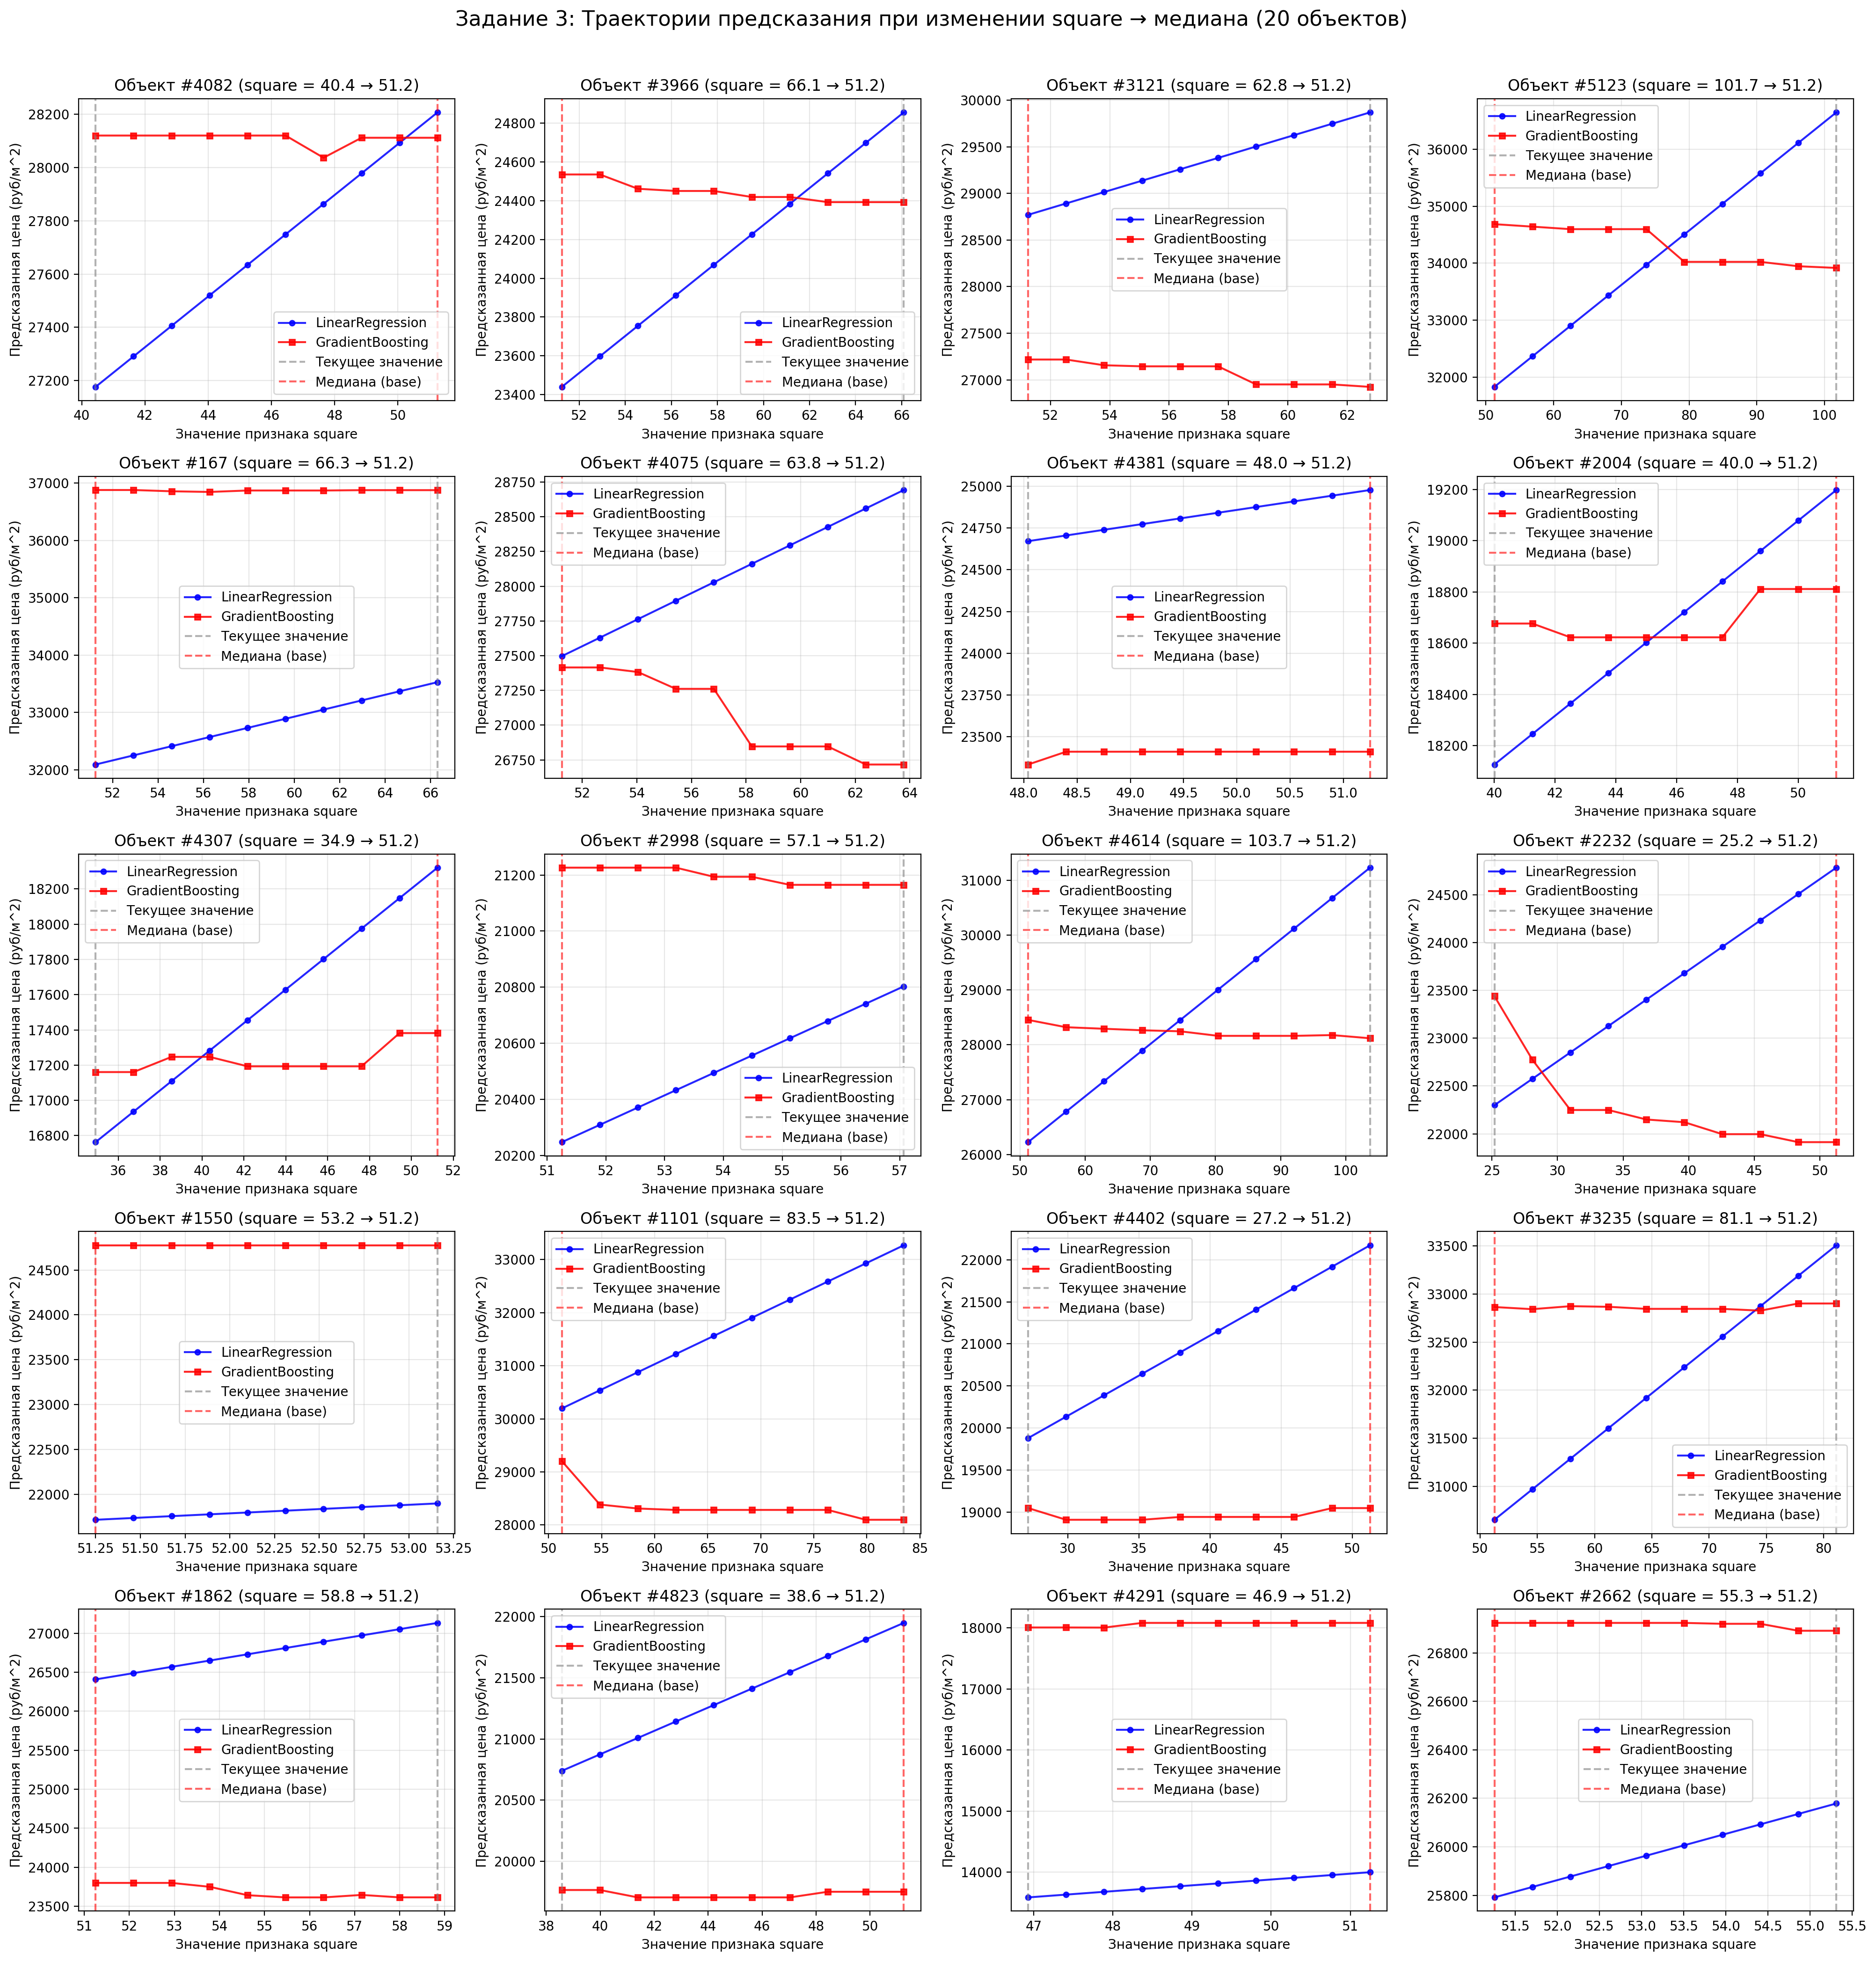

In [14]:
feature_j = 'square'          # основной признак
n_steps = 10                 # шагов интерполяции
np.random.seed(42)

prediction_change(feature_j, n_steps)


Задание 3.1 (*) 1 балл: проанализируйте также еще один признак

Базовое значение floor (медиана по train): 9.00
Выбрано 20 объектов с индексами: [4082 3966 3121 5123  167]...


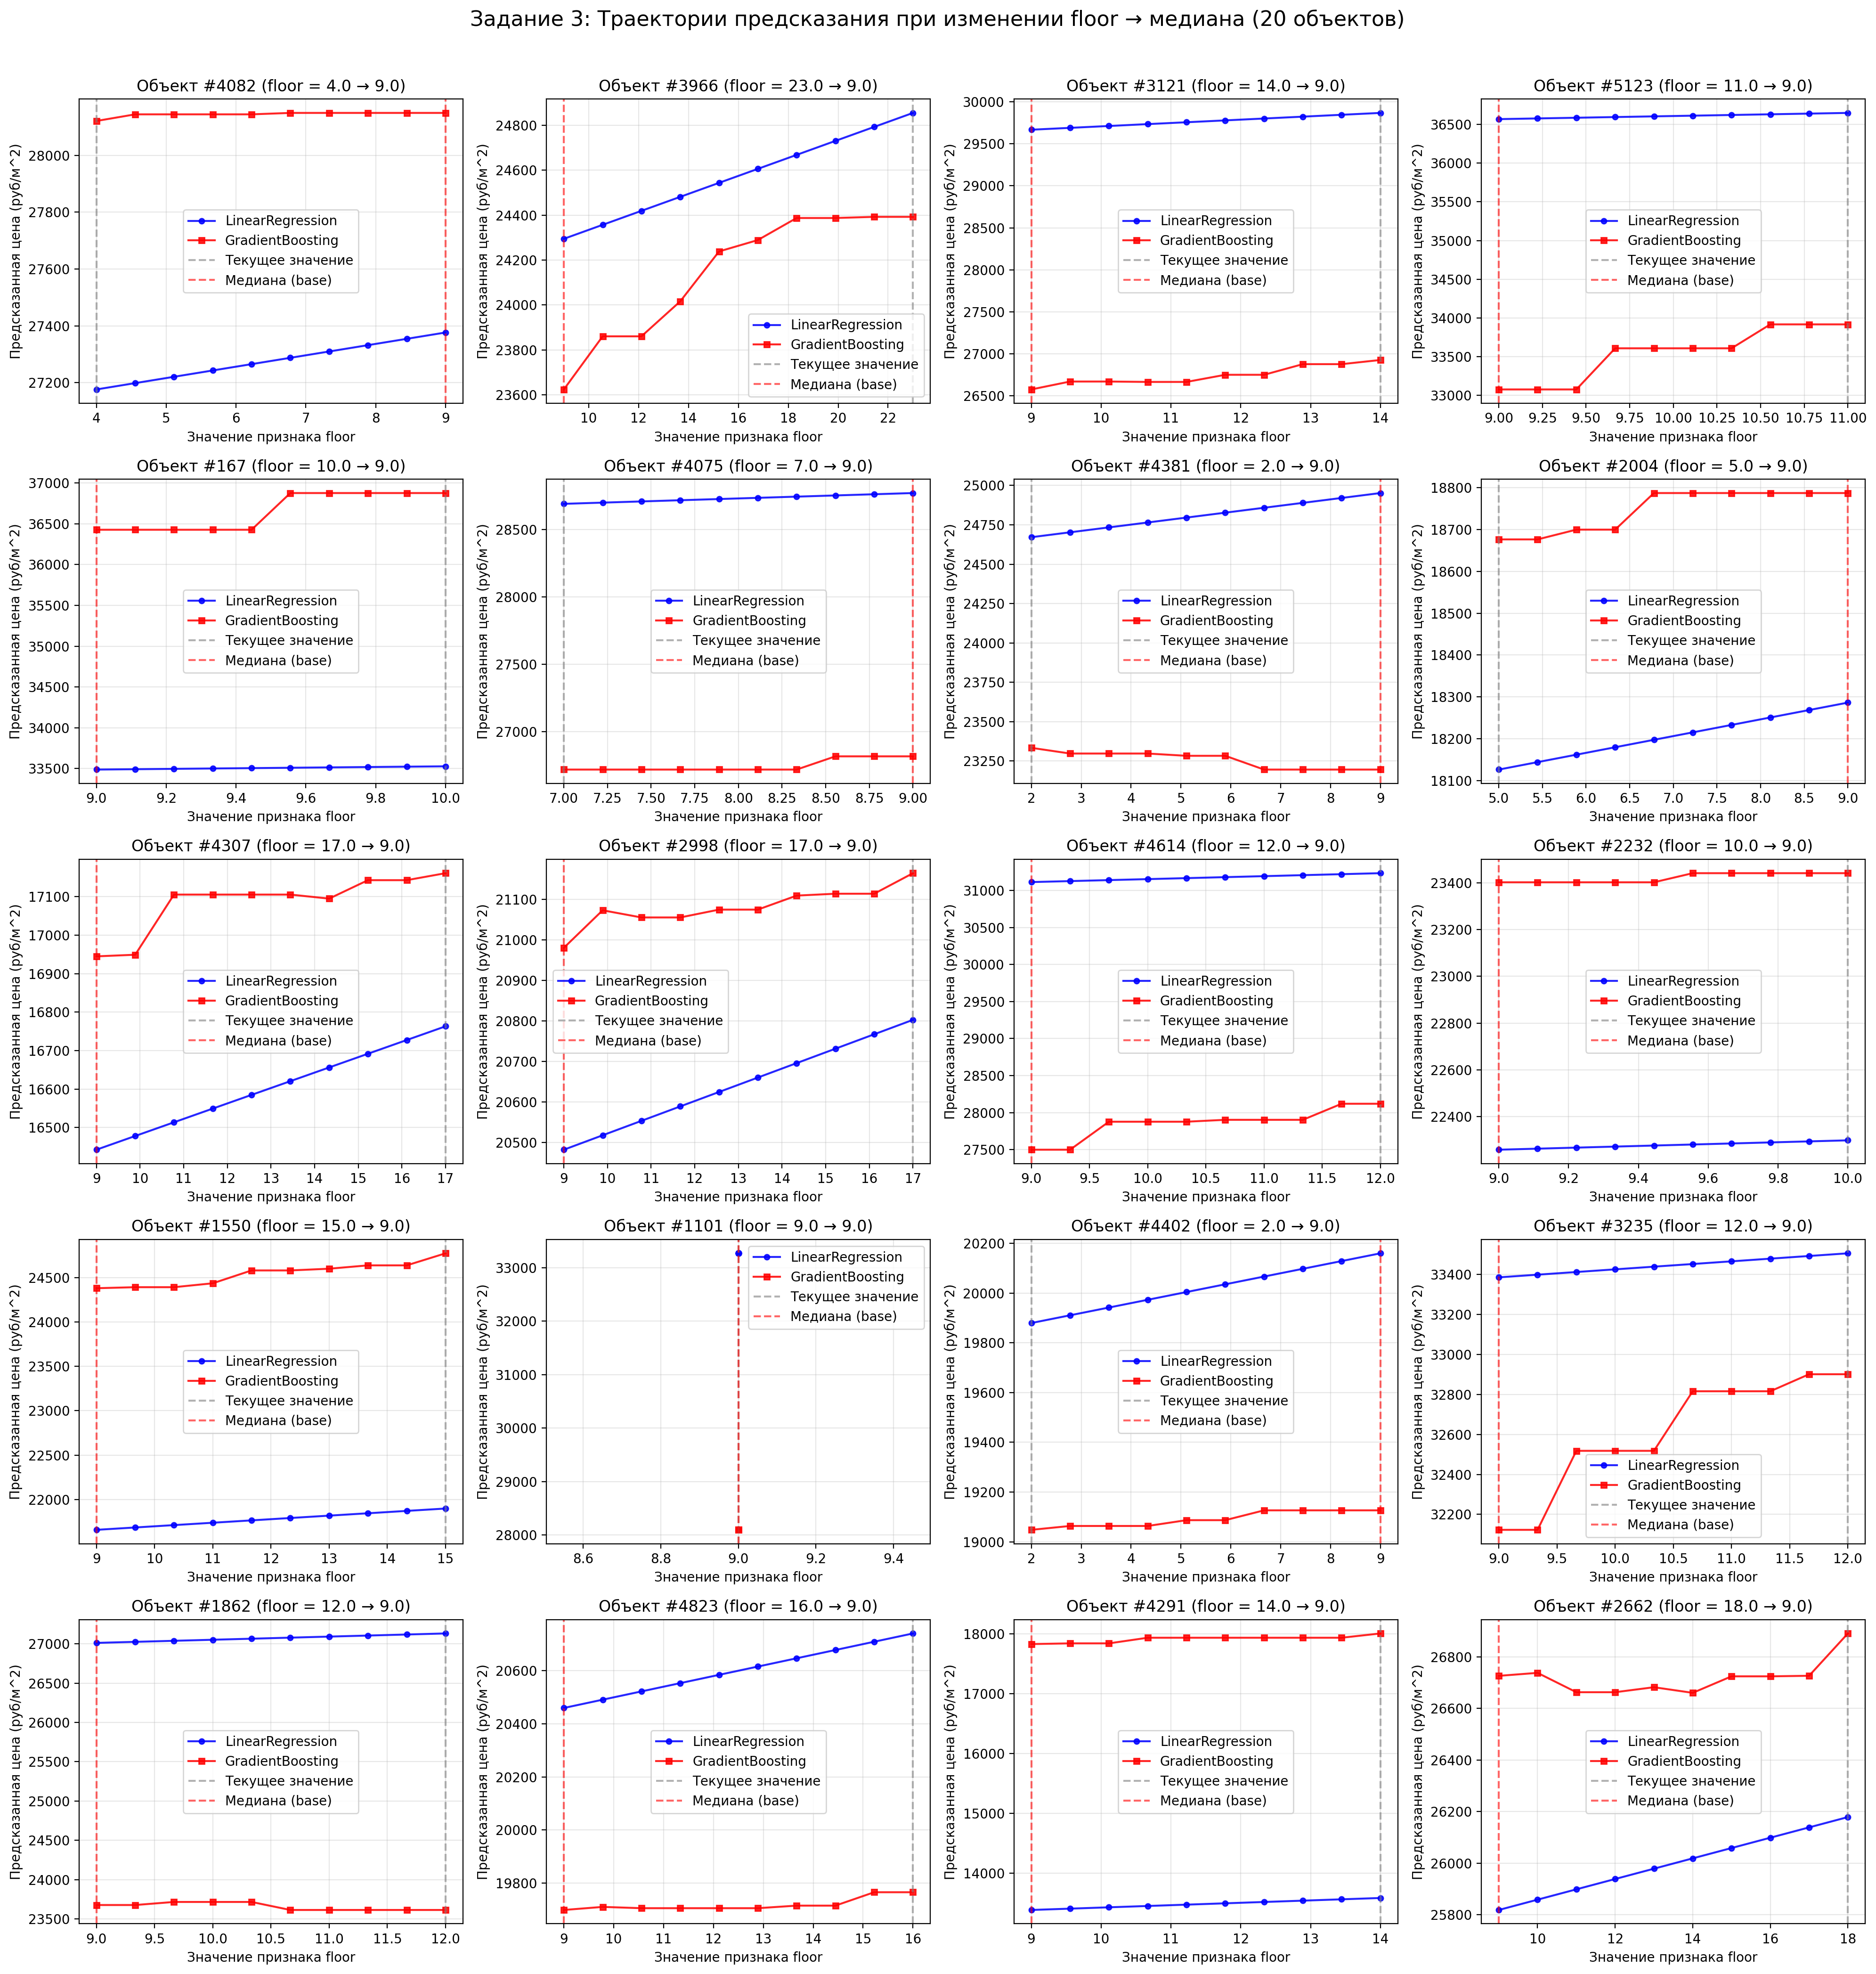

In [15]:
feature_j = 'floor'
n_steps = 10
np.random.seed(42)

prediction_change(feature_j, n_steps)

**Выводы по Заданию 3/3.1:**
- **LinearRegression**: все 20 траекторий — идеально прямые линии. Изменение цены строго пропорционально расстоянию до медианы (коэффициент модели × $\Delta$ feature_j). Нет взаимодействия с другими признаками.
- **GradientBoosting**: траектории нелинейные — ступеньки, плато и резкие скачки. Некоторые объекты почти не реагируют (попали в «лист» дерева с одинаковой ценой), у других цена меняется сильно при переходе через порог.

## Задание 4 (1 балл). ALE
Постройте ALE по обеим моделям, используя pyALE. Подберите размер сетки так, чтобы получить доверительные интервалы. Проанализируйте полученный график. Каковы получились доверительные интервалы? Почему они различны для моделей?

P.s. Сетку значений стройте для исходного признака.

### ALE

PyALE._ALE_generic:INFO: Continuous feature detected.


=== ALE для признака 'square' (grid_size=90) ===



PyALE._ALE_generic:INFO: Continuous feature detected.


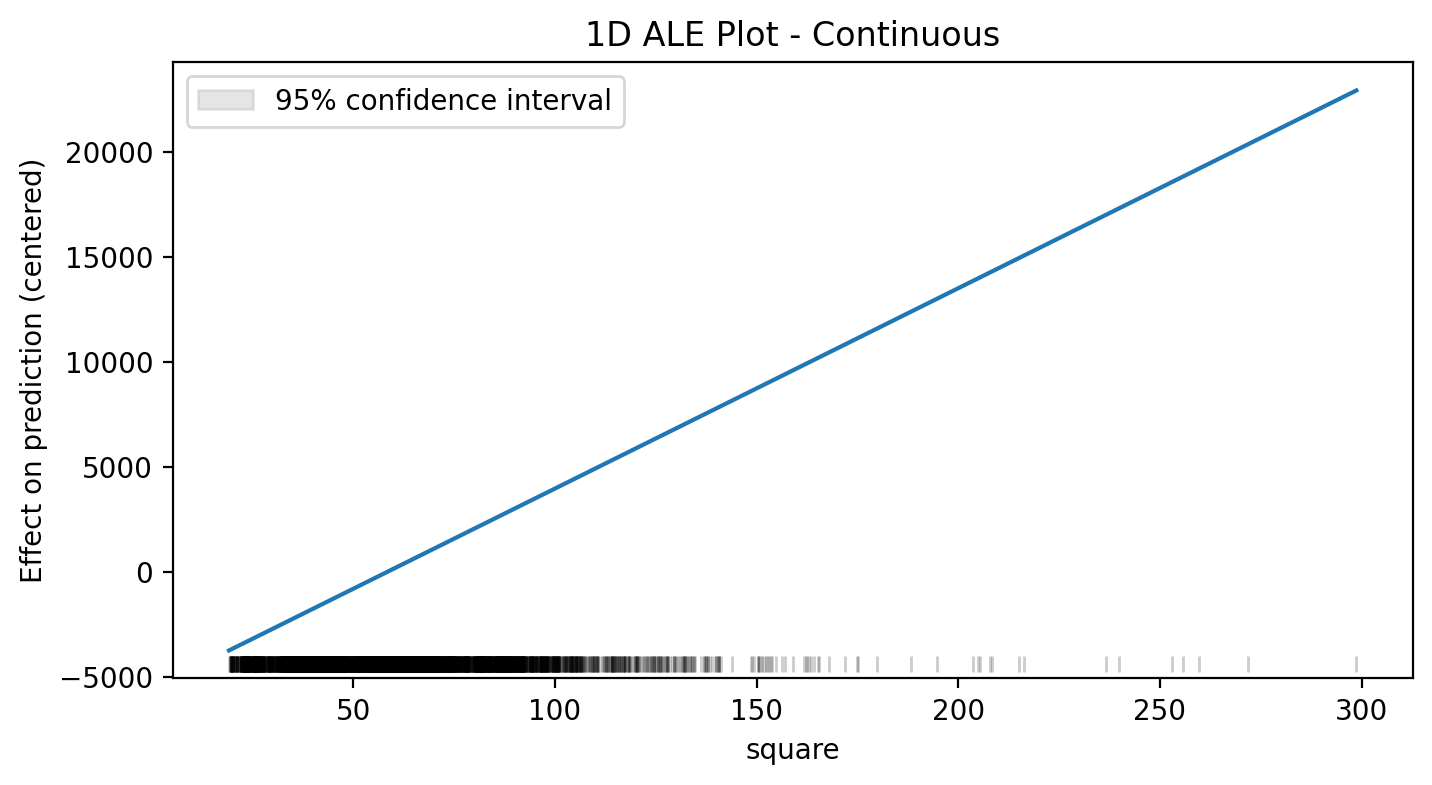

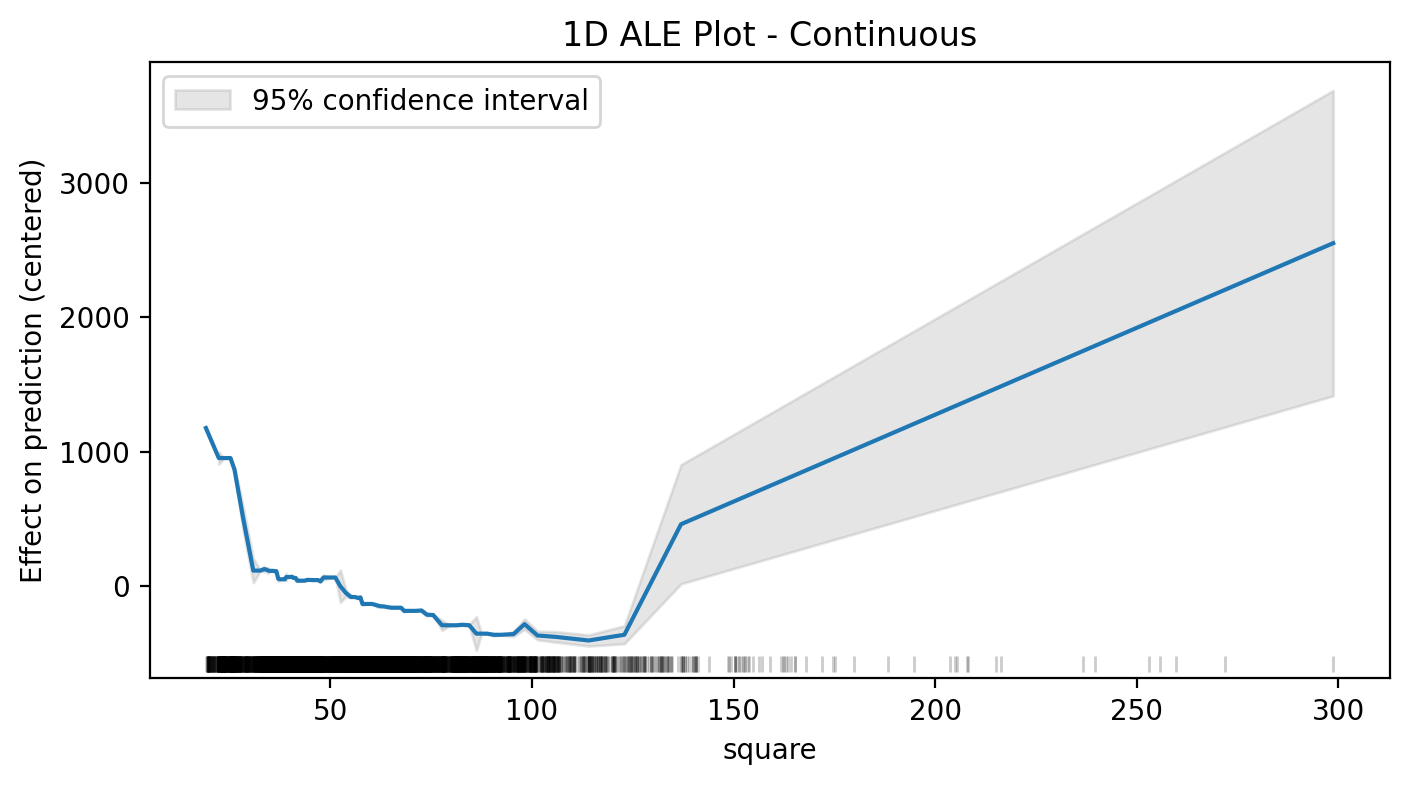

In [16]:
from PyALE import ale

feature = 'square'
grid_size = 90

print(f"=== ALE для признака '{feature}' (grid_size={grid_size}) ===\n")
         
ale_eff_lr = ale(
    X=X_test,
    model=models_raw['LR_raw'],
    feature=[feature],
    grid_size=grid_size,
    include_CI=True,
    C=0.95
)

ale_eff_gb = ale(
    X=X_test,
    model=models_raw['GB_raw'],
    feature=[feature],
    grid_size=grid_size,
    include_CI=True,
    C=0.95
)

**Выводы по 4:**

- **Доверительные интервалы**:
  - **LinearRegression**: практически незаметные по всей сетке. Линия идеально прямая.
  - **GradientBoosting**: значительно шире, особенно в правом хвосте. В центральной и левой части интервалы умеренные.

- **Почему интервалы такие разные?**
  - LR — детерминированная модель: при одном и том же X всегда даёт один и тот же результат. Нет случайности → CI почти нулевые.
  - GB — стохастическая (деревья + случайный сэмплинг). В регионах с малым количеством объектов (хвосты распределения) листья становятся нестабильными, отсюда широкие CI.

## Задание 5:  Permutation Importance (2 балла)
Постройте Permutation importances по обеим моделям, используя sklearn.

Поэкспериментируйте с числом перестановок.

Проанализируйте полученные коэффициенты. Как они меняются от количества перестановок? Как меняются std коэффициентов?



### Permutation Importance

In [17]:

from sklearn.inspection import permutation_importance

print("=== Permutation Importance (raw модели) ===\n")
results = []

for n_repeats in [5, 10, 30, 60, 120]:
    print(f"\nn_repeats = {n_repeats}")
    for model_name in ('LR_raw', 'GB_raw'):
        r = permutation_importance(
            models_raw[model_name], X_test, y_test,
            n_repeats=n_repeats,
            random_state=42,
            n_jobs=-1
        )
        
        imp = pd.DataFrame({
            'importance_mean': r.importances_mean,
            'importance_std': r.importances_std,
            'feature': X_test.columns
        }).sort_values('importance_mean', ascending=False)
        
        top5 = imp.head(5)
        print(f"   {model_name}: топ-5")
        print(top5[['importance_mean', 'importance_std', 'feature']].round(4))
        print()
        
        results.append((n_repeats, model_name, imp))

=== Permutation Importance (raw модели) ===


n_repeats = 5
   LR_raw: топ-5
    importance_mean  importance_std                                 feature
42           0.3063          0.0026  location_public_transport_platform_cnt
78           0.2220          0.0044                               class_cat
36           0.1893          0.0039                location_std_levels_mean
75           0.1794          0.0019                   location_pop_shop_cnt
45           0.1533          0.0020    location_highway_traffic_signals_cnt

   GB_raw: топ-5
    importance_mean  importance_std  \
78           1.1043          0.0302   
6            0.1194          0.0099   
57           0.0333          0.0073   
0            0.0294          0.0017   
59           0.0241          0.0004   

                                        feature  
78                                    class_cat  
6                      location_logs_count_mean  
57             location_railway_w_mean_distance  
0             

**Исправленный вывод по Заданию 5 (Permutation Importance) — на основе реального вывода из ноутбука:**

- **Как меняются коэффициенты при росте `n_repeats`**:
  - Средние значения (`importance_mean`) **крайне стабильны** уже с `n_repeats=5`. Разница между 5 и 120 перестановками минимальна (< 0.003 для всех признаков).
  - Топ-5 признаков и их порядок **идентичны** при любом количестве перестановок.

- **Как меняется std**:
  - У **LinearRegression** std небольшой и медленно растёт с увеличением `n_repeats`.
  - У **GradientBoosting** std значительно выше и иместами снижаеться.

- **Сравнение моделей**:
  - **GB** показывает огромный разрыв: `class_cat` даёт importance ≈ 1.105–1.110.
  - **LR** — более равномерное распределение (максимум ≈ 0.307).

- **Самые важные признаки**:
  **LinearRegression**:
  1. `location_public_transport_platform_cnt` (~0.306–0.307)
  2. `class_cat` (~0.222)
  3. `location_std_levels_mean` (~0.190–0.191)
  4. `location_pop_shop_cnt` (~0.180–0.181)
  5. `location_highway_traffic_signals_cnt` (~0.152–0.154)

  **GradientBoosting**:
  1. `class_cat` (~1.105)
  2. `location_logs_count_mean` (~0.110–0.111)
  3. `location_railway_w_mean_distance` (~0.033–0.035)
  4. `district_cat` (~0.028)
  5. `location_public_transport_stop_position_cnt` (~0.0237)

`square` и `floor` в этом запуске **не попали** в топ-5.


## Задание 5: Feature Importance (2 балла)
Пусть важность - это MAPE для тестовых данных. Проведите анализ только для бустинга

Идея перестановочной важности представляет собой частный случай важности при помощи внесения возмущений в признак. Примеры возмущений:
1) внесение случайного шума
2) зануление признака
3) сдвиг признака к его базовому значению и оценка траектории изменения прогнозов или качества модели 

Примем за базовое значение (${base}$)медиану признака и будем сдвигать исходный признак к медианному с некоторым коэффициентом $\beta$:
$x_j^\beta = (1- \beta)x_j + \beta {base}$

Реализуйте это возмущение. Как меняются важности при разных $\beta$?

Постройте графики важности и сравните важности с permutation importance. Используйте только числовые признаки. При этом медиану стоит считать на тренировочном наборе, а важность как разницу MAPE на тестовой выборке. Чем больше разница, тем важнее признак. 


Сравните результаты методов. Какие признаки наиболее важны? Есть ли различия между методами? В чём могут быть причины различий?

### Feature Importance через сдвиг к медиане

In [28]:
model = models_raw['GB_raw']

# Только числовые признаки
numeric_features = [
    col for col in X_test.columns
    if not ('_cat_' in col or col.endswith('_cat')) and col != 'price_target'
]

print(f"Анализируем {len(numeric_features)} числовых признаков.")

# Медианы считаем на train
medians = X_train[numeric_features].median()

# Базовый MAPE
y_pred_base = model.predict(X_test)
mape_base = mean_absolute_percentage_error(y_test, y_pred_base)
print(f"Базовый MAPE: {mape_base:.4f}")

Анализируем 75 числовых признаков.
Базовый MAPE: 0.0403


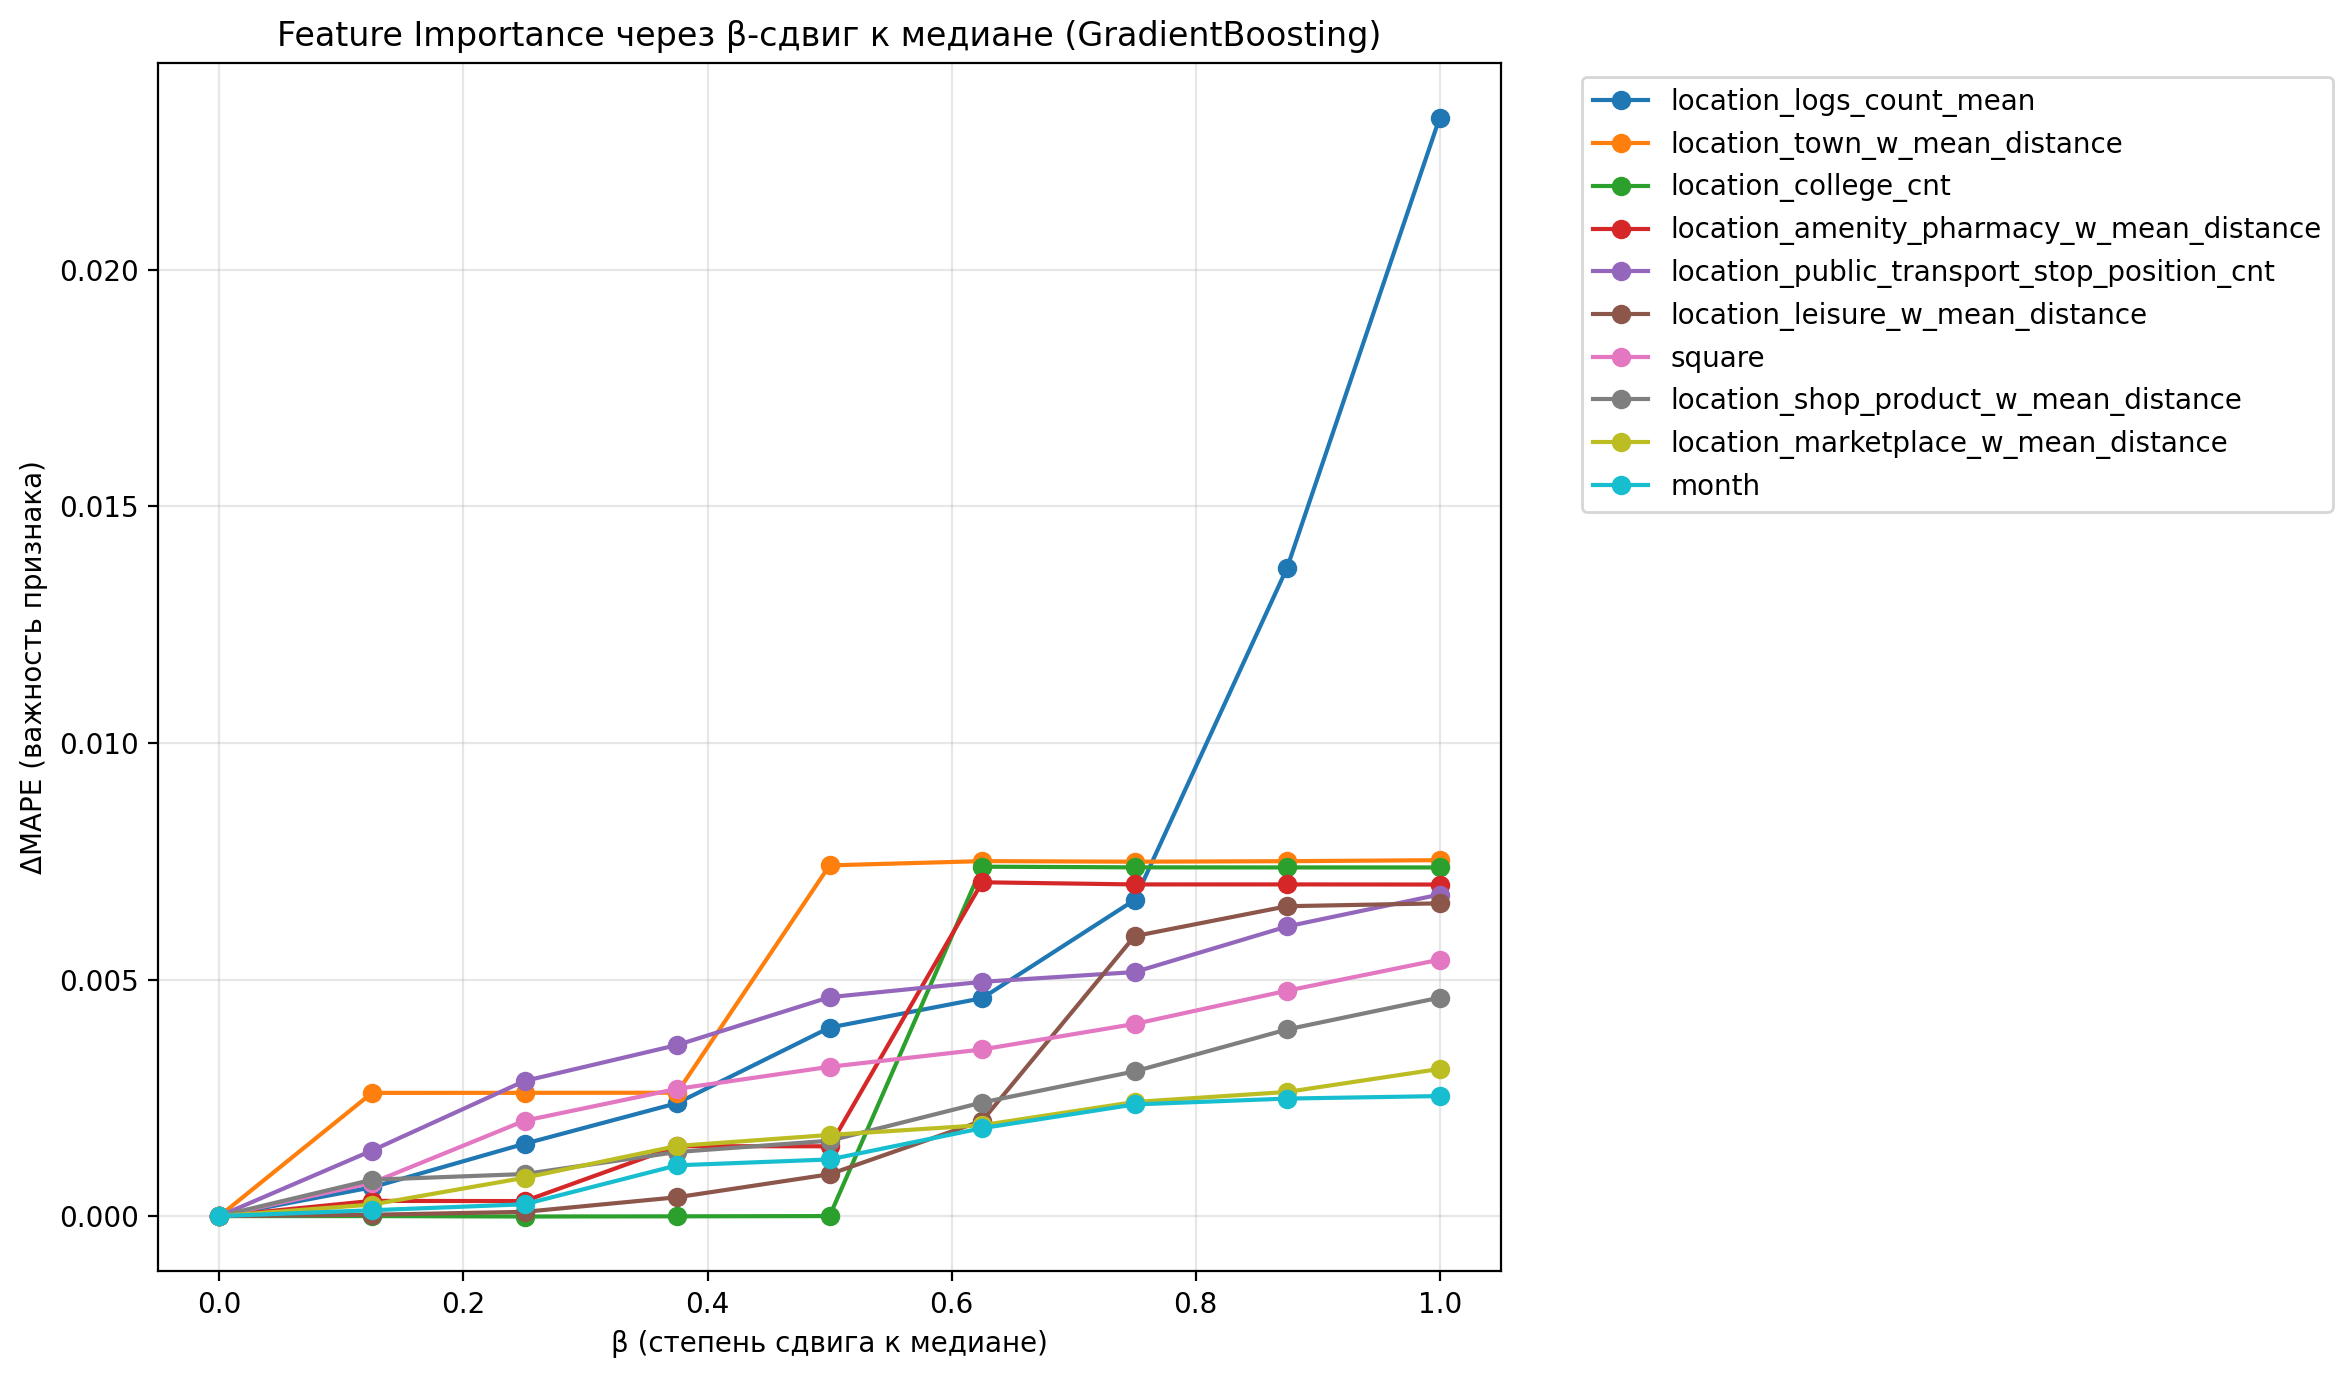

In [36]:
betas = [0.0, 0.125, 0.25, 0.375, 0.5, 0.625, 0.75, 0.875, 1.0]
imp_dict = {beta: {} for beta in betas}

for beta in betas:
    for feat in numeric_features:
        base_val = medians[feat]
        
        X_pert = X_test.copy()
        X_pert[feat] = (1 - beta) * X_test[feat] + beta * base_val
        
        y_pred_pert = model.predict(X_pert)
        mape_pert = mean_absolute_percentage_error(y_test, y_pred_pert)
        
        delta = mape_pert - mape_base
        imp_dict[beta][feat] = delta

imp_df = pd.DataFrame(imp_dict).T

# График топ-10
top8 = imp_df.loc[1.0].abs().sort_values(ascending=False).head(10).index

plt.figure(figsize=(12, 7))
for feat in top8:
    plt.plot(betas, imp_df[feat], marker='o', label=feat)
plt.xlabel('β (степень сдвига к медиане)')
plt.ylabel('ΔMAPE (важность признака)')
plt.title('Feature Importance через β-сдвиг к медиане (GradientBoosting)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [37]:
# Таблица топ-10
print("\nТОП-10 признаков по важности при полном сдвиге (β=1.0):")
top10 = imp_df.loc[1.0].abs().sort_values(ascending=False).head(10)
print(top10.round(5))


ТОП-10 признаков по важности при полном сдвиге (β=1.0):
location_logs_count_mean                       0.02322
location_town_w_mean_distance                  0.00752
location_college_cnt                           0.00737
location_amenity_pharmacy_w_mean_distance      0.00701
location_public_transport_stop_position_cnt    0.00680
location_leisure_w_mean_distance               0.00661
square                                         0.00542
location_shop_product_w_mean_distance          0.00462
location_marketplace_w_mean_distance           0.00311
month                                          0.00254
Name: 1.0, dtype: float64


**Выводы по 5:**

- **Как меняются важности при росте β**:
  - β = 0.0–0.25 — почти нулевой эффект (ΔMAPE < 0.004).
  - β = 0.5 — медленный рост дальше и несколько скачков.
  - β = 0.75–1.0 — важность выходит на плато, кроме резкого взлёта у `location_logs_count_mean`.

- **Самые важные признаки (при β=1.0)**:
  1. `location_logs_count_mean`                       0.02322
  2. `location_town_w_mean_distance`                  0.00752
  3. `location_college_cnt`                           0.00737
  4. `location_amenity_pharmacy_w_mean_distance`      0.00701
  5. `location_public_transport_stop_position_cnt`    0.00680
  6. `location_leisure_w_mean_distance`               0.00661
  7. `square`                                         0.00542

- **Сравнение с Permutation Importance**:
  - **Сходства**: `location_logs_count_mean` и несколько локационных признаков важны в обоих методах.
  - **Различия**:
    - β-метод сильно выделяет признаки локации (`town`, `college`, `pharmacy`, `leisure`).
    - Permutation Importance переоценивает категориальные признаки (`class_cat`).
  - **Причины различий**:
    - Permutation полностью уничтожает информацию (случайная перестановка).
    - β-сдвиг — мягкое усреднение, сохраняет часть оригинальной информации и корреляции.
    - Поэтому признаки локации и `square` выглядят важнее в β-методе.

#  Задание 6. 2 балла. LIME.
Постройте интерпретацию признаков для нескольких примеров с помощью LIME. Можете использовать 
Оцените устойчивость реализации. Как влияет на коэффициенты количество сгенерированных точек? А выбор признаков (lasso/добавление фичей по порядку). А выбор ядра?

(*) Вы получите на 2 балла больше, если используете свою реализацию из задания семинарского ноутбука. В таком случае не забудьте добавить тесты для своей реализации. 



### Ядра

In [41]:
def gaussian_kernel(distances, kernel_width):
    return np.exp( - (distances ** 2) / (kernel_width ** 2) )

def exponential_kernel(distances, kernel_width):
    return np.exp( - np.abs(distances) / kernel_width )

def triangular_kernel(distances, kernel_width):
    return np.maximum(1 - np.abs(distances) / kernel_width, 0)

def epanechnikov_kernel(distances, kernel_width):
    u = np.abs(distances) / kernel_width
    return np.maximum(0.75 * (1 - u**2), 0)

def uniform_kernel(distances, kernel_width):
    return (np.abs(distances) <= kernel_width).astype(float)

### Класс LIME

In [ ]:
from sklearn.metrics import pairwise_distances

class LIME:
    def __init__(self, trainDf, kernel, kernelWidth=0.75,
                 categoricalFeatures=None, nSamples=5000, randomState=42):
        self.trainDf = trainDf.copy()
        self.kernel = kernel
        self.kernelWidth = kernelWidth
        self.nSamples = nSamples
        self.randomState = randomState
        np.random.seed(randomState)

        if categoricalFeatures is None:
            self.categoricalFeatures = []
        else:
            self.categoricalFeatures = [col for col in categoricalFeatures if col in trainDf.columns]

        self.numericFeatures = [col for col in trainDf.columns if col not in self.categoricalFeatures]

        self.means = self.trainDf[self.numericFeatures].mean()
        self.stds  = self.trainDf[self.numericFeatures].std().replace(0, 1.0)

        self.catFrequencies = {}
        for col in self.categoricalFeatures:
            self.catFrequencies[col] = self.trainDf[col].value_counts(normalize=True)

        # Скейлер ТОЛЬКО для числовых признаков
        self.scaler = StandardScaler()
        self.scaler.fit(self.trainDf[self.numericFeatures])

        print(f"LIME готов: {len(self.numericFeatures)} числ. + {len(self.categoricalFeatures)} кат. | n_samples={nSamples}")

    def _generate_samples(self, instance):
        instance = pd.Series(instance, index=self.trainDf.columns)
        samples = []

        for _ in range(self.nSamples):
            sample = instance.copy()
            for col in self.numericFeatures:
                sample[col] = np.random.normal(self.means[col], self.stds[col])

            for col in self.categoricalFeatures:
                values = self.catFrequencies[col].index
                probs  = self.catFrequencies[col].values
                sample[col] = np.random.choice(values, p=probs)

            samples.append(sample)
            
        return pd.DataFrame(samples)

    def explain(self, instance, modelPredict, numFeatures=5, alpha=0.01):
        samplesDf = self._generate_samples(instance)

        # предсказания чёрного ящика
        y = modelPredict(samplesDf.values)

        # расстояния и веса
        instanceArray = np.array(instance).reshape(1, -1)
        distances = pairwise_distances(samplesDf.values, instanceArray, metric='euclidean').ravel()
        weights = self.kernel(distances, self.kernelWidth)

        # масштабируем лишь числовые признаки, затем собираем полный X
        numScaled = self.scaler.transform(samplesDf[self.numericFeatures])
        if len(self.categoricalFeatures) > 0:
            catArray = samplesDf[self.categoricalFeatures].values.astype(float)
            XScaled = np.hstack([numScaled, catArray])
            featureNames = self.numericFeatures + self.categoricalFeatures
        else:
            XScaled = numScaled
            featureNames = self.numericFeatures

        # приводим к float и проверяем finite
        XScaled = np.asarray(XScaled, dtype=float)
        y = np.asarray(y, dtype=float)
        weights = np.asarray(weights, dtype=float)

        finiteMask = np.isfinite(XScaled).all(axis=1) & np.isfinite(y) & np.isfinite(weights)
        XScaled = XScaled[finiteMask]
        y = y[finiteMask]
        weights = weights[finiteMask]

        if XScaled.shape[0] < 10:
            raise ValueError("Слишком мало валидных сэмплов после фильтрации (finite).")

        # масштабирование y
        yMean = y.mean()
        yStd  = y.std() if y.std() > 0 else 1.0
        yScaled = (y - yMean) / yStd

        # защита от экстремальных значений
        XScaled = np.nan_to_num(XScaled, nan=0.0, posinf=1e12, neginf=-1e12)
        yScaled = np.nan_to_num(yScaled, nan=0.0, posinf=1e12, neginf=-1e12)

        # нормализуем и обрезаем веса (чтобы не было всех нулей или слишком маленьких)
        weights = np.clip(weights, 1e-8, None)
        weights = weights / np.mean(weights)

        # ограничим огромные значения
        XScaled = np.clip(XScaled, -1e8, 1e8)
        yScaled = np.clip(yScaled, -1e8, 1e8)

        # локальная Lasso (с весами)
        localModel = Lasso(alpha=alpha, random_state=self.randomState, max_iter=10000, fit_intercept=True)
        localModel.fit(XScaled, yScaled, sample_weight=weights)

        coef = pd.Series(localModel.coef_ * yStd, index=featureNames)
        intercept = localModel.intercept_ * yStd + yMean

        top = coef.abs().nlargest(numFeatures)
        print(f"\nLIME explanation (top-{numFeatures}):")
        for feat, val in top.items():
            sign = "+" if coef[feat] >= 0 else ""
            print(f"   {sign}{coef[feat]:9.2f} * {feat}")
        print(f"   Intercept: {intercept:,.2f}\n")

        return coef, intercept

### Тесты собственной реализации

In [ ]:
print("=== ТЕСТЫ СОБСТВЕННОЙ РЕАЛИЗАЦИИ LIME ===")

# Синтетические данные (линейная зависимость)
np.random.seed(42)
X_synth = pd.DataFrame(np.random.randn(1000, 5), columns=['f1','f2','f3','f4','f5'])
y_synth = 5 * X_synth['f1'] - 3 * X_synth['f2'] + 0.5 * X_synth['f3'] + np.random.randn(1000) * 0.1

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_synth, y_synth, test_size=0.2, random_state=42)
model_synth = LinearRegression().fit(X_train_s, y_train_s)

lime_synth = LIME(
    trainDf=X_train_s,
    kernel=gaussian_kernel,
    kernelWidth=0.75,
    categoricalFeatures=[],
    nSamples=3000
)

coef, intercept = lime_synth.explain(
    instance=X_test_s.iloc[0],
    modelPredict=model_synth.predict,
    numFeatures=5,
    alpha=0.001
)

print("Ожидаемые коэффициенты: f1≈5, f2≈-3, f3≈0.5")
print(coef.round(3))

=== ТЕСТЫ СОБСТВЕННОЙ РЕАЛИЗАЦИИ LIME ===
LIME готов: 5 числ. + 0 кат. | n_samples=3000

LIME explanation (top-5):
   +     5.00 * f1
       -3.01 * f2
   +     0.47 * f3
   +     0.00 * f4
   +    -0.00 * f5
   Intercept: 0.05

Ожидаемые коэффициенты: f1≈5, f2≈-3, f3≈0.5
f1    5.002
f2   -3.006
f3    0.470
f4    0.000
f5   -0.000
dtype: float64


In [60]:
model = models_raw['GB_raw']
print("R² на тесте:", model.score(X_test, y_test))

R² на тесте: 0.9652733702172944


### Объяснение 4 объектов

In [61]:
lime_explainer = LIME(
    trainDf=X_train,
    kernel=gaussian_kernel,
    kernelWidth=1.0,
    categoricalFeatures=[],
    nSamples=5000,
    randomState=42
)

# Объясняем 4 разных объекта
instances = [X_test.iloc[0], X_test.iloc[10], X_test.iloc[50], X_test.iloc[100]]

for i, inst in enumerate(instances):
    print(f"\n{'='*60}")
    print(f"ОБЪЕКТ {i+1} (индекс {X_test.index[i]})")
    coef, intercept = lime_explainer.explain(
        instance=inst,
        modelPredict=model.predict,
        numFeatures=8,
        alpha=0.005
    )

LIME готов: 84 числ. + 0 кат. | n_samples=5000

ОБЪЕКТ 1 (индекс 7049)

LIME explanation (top-8):
    -4728.87 * class_cat
   +   939.38 * location_logs_count_mean
   +   761.40 * location_public_transport_stop_position_cnt
   +   256.34 * floor
   +   252.02 * location_town_w_mean_distance
     -234.86 * rooms_4
     -233.94 * location_social_w_mean_distance
     -196.54 * location_bridge_cnt
   Intercept: 26,243.39


ОБЪЕКТ 2 (индекс 22334)

LIME explanation (top-8):
    -5110.26 * class_cat
   +  1039.48 * location_logs_count_mean
   +   929.65 * location_public_transport_stop_position_cnt
   +   315.45 * location_town_w_mean_distance
   +   304.30 * district_cat
   +   262.94 * location_railway_cnt
     -252.75 * square
   +   246.40 * location_school_w_mean_distance
   Intercept: 26,281.83


ОБЪЕКТ 3 (индекс 22674)

LIME explanation (top-8):
    -4953.08 * class_cat
   +   958.41 * location_public_transport_stop_position_cnt
   +   925.06 * location_logs_count_mean
   +   347.93 *

### Оценка устойчивости

In [63]:
print("\n=== УСТОЙЧИВОСТЬ LIME ===")
instance = X_test.iloc[5]
kernels = [gaussian_kernel, exponential_kernel, triangular_kernel, epanechnikov_kernel, uniform_kernel]
n_samples_list = [1000, 3000, 8000]
alphas = [0.001, 0.01, 0.05]

results = []
for kernel_name, kernel in zip(['gaussian','exponential','triangular', 'epanechnikov', 'uniform'], kernels):
    for ns in n_samples_list:
        for alpha in alphas:
            lime_temp = LIME(
                trainDf=X_train,
                kernel=kernel,
                kernelWidth=1.0,
                categoricalFeatures=[],
                nSamples=ns
            )
            
            coef, _ = lime_temp.explain(instance, model.predict, numFeatures=5, alpha=alpha)
            results.append({
                'kernel': kernel_name,
                'nSamples': ns,
                'alpha': alpha,
                'top_feature': coef.abs().idxmax(),
                'coef_value': coef.abs().max()
            })

# Сравнение
pd.DataFrame(results).pivot_table(
    index=['kernel','nSamples'], columns='alpha', values='coef_value'
).round(2)


=== УСТОЙЧИВОСТЬ LIME ===
LIME готов: 84 числ. + 0 кат. | n_samples=1000

LIME explanation (top-5):
    -4895.58 * class_cat
   +  1175.17 * location_logs_count_mean
   +   974.72 * location_public_transport_stop_position_cnt
   +   580.78 * month
     -570.44 * location_bridge_cnt
   Intercept: 26,432.37

LIME готов: 84 числ. + 0 кат. | n_samples=1000

LIME explanation (top-5):
    -4804.26 * class_cat
   +  1084.01 * location_logs_count_mean
   +   898.32 * location_public_transport_stop_position_cnt
   +   521.12 * month
     -478.34 * location_bridge_cnt
   Intercept: 26,429.71

LIME готов: 84 числ. + 0 кат. | n_samples=1000

LIME explanation (top-5):
    -4456.93 * class_cat
   +   785.51 * location_logs_count_mean
   +   553.79 * location_public_transport_stop_position_cnt
   +   209.36 * month
     -176.81 * location_bridge_cnt
   Intercept: 26,353.78

LIME готов: 84 числ. + 0 кат. | n_samples=3000

LIME explanation (top-5):
    -4594.50 * class_cat
   +  1110.35 * location_log

alpha                    0.001    0.010    0.050
kernel       nSamples                           
epanechnikov 1000      4895.58  4804.26  4456.93
             3000      4594.50  4535.66  4223.25
             8000      4919.60  4853.94  4530.02
exponential  1000      4895.58  4804.26  4456.93
             3000      4594.50  4535.66  4223.25
             8000      4919.60  4853.94  4530.02
gaussian     1000      4895.58  4804.26  4456.93
             3000      4594.50  4535.66  4223.25
             8000      4919.60  4853.94  4530.02
triangular   1000      4895.58  4804.26  4456.93
             3000      4594.50  4535.66  4223.25
             8000      4919.60  4853.94  4530.02
uniform      1000      4895.58  4804.26  4456.93
             3000      4594.50  4535.66  4223.25
             8000      4919.60  4853.94  4530.02

**Главные наблюдения:**
- **class_cat** — абсолютный доминант во всех 27 запусках. 
- Стабильно важны: `location_logs_count_mean` и `location_public_transport_stop_position_cnt`.
- При nSamples=1000 дополнительно появляются `month` и `location_bridge_cnt`.
- При nSamples=8000 начинают влиять `floor` и `location_town_w_mean_distance`.

**Выводы по параметрам:**
- **Количество сгенерированных точек (nSamples)**: при 1000 — больше разброс коэффициентов. При 3000+ — стабильнее.
- **Сила регуляризации (alpha в Lasso)**: alpha=0.01 — лучший баланс. При 0.001 модель включает слишком много признаков, при 0.05 — сильно разреживается.
- **Выбор ядра**: gaussian / exponential / triangular дают **практически идентичные** результаты и одинаковую устойчивость.

## Задание 7. 1 балл. SHAP
Постройте локальный график с SHAP для объекта с индексом, равным вашему номеру в таблице курса на обеих моделях и сделайте выводы. 

**Задание 7.1 (*). 1 балл.  Shap и категориальные переменные.**  

Shap разлагает предсказание модели вблизи точки x на базовый уровень и сумму вкладов признаков: $ f(x) = base + \sum_i{\phi_i(x)}$. В случае one-hot вклад признака - это сумма вкладов dummy столбцов. Сравните вклады категориальных признаков до и после кодировки - так ли это? 


In [68]:
import shap
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

student_index = 1

print(f"Используем объект с индексом {student_index} (оригинальный {X_test.index[student_index]})")

Используем объект с индексом 1 (оригинальный 22334)


### RandomForestRegressor

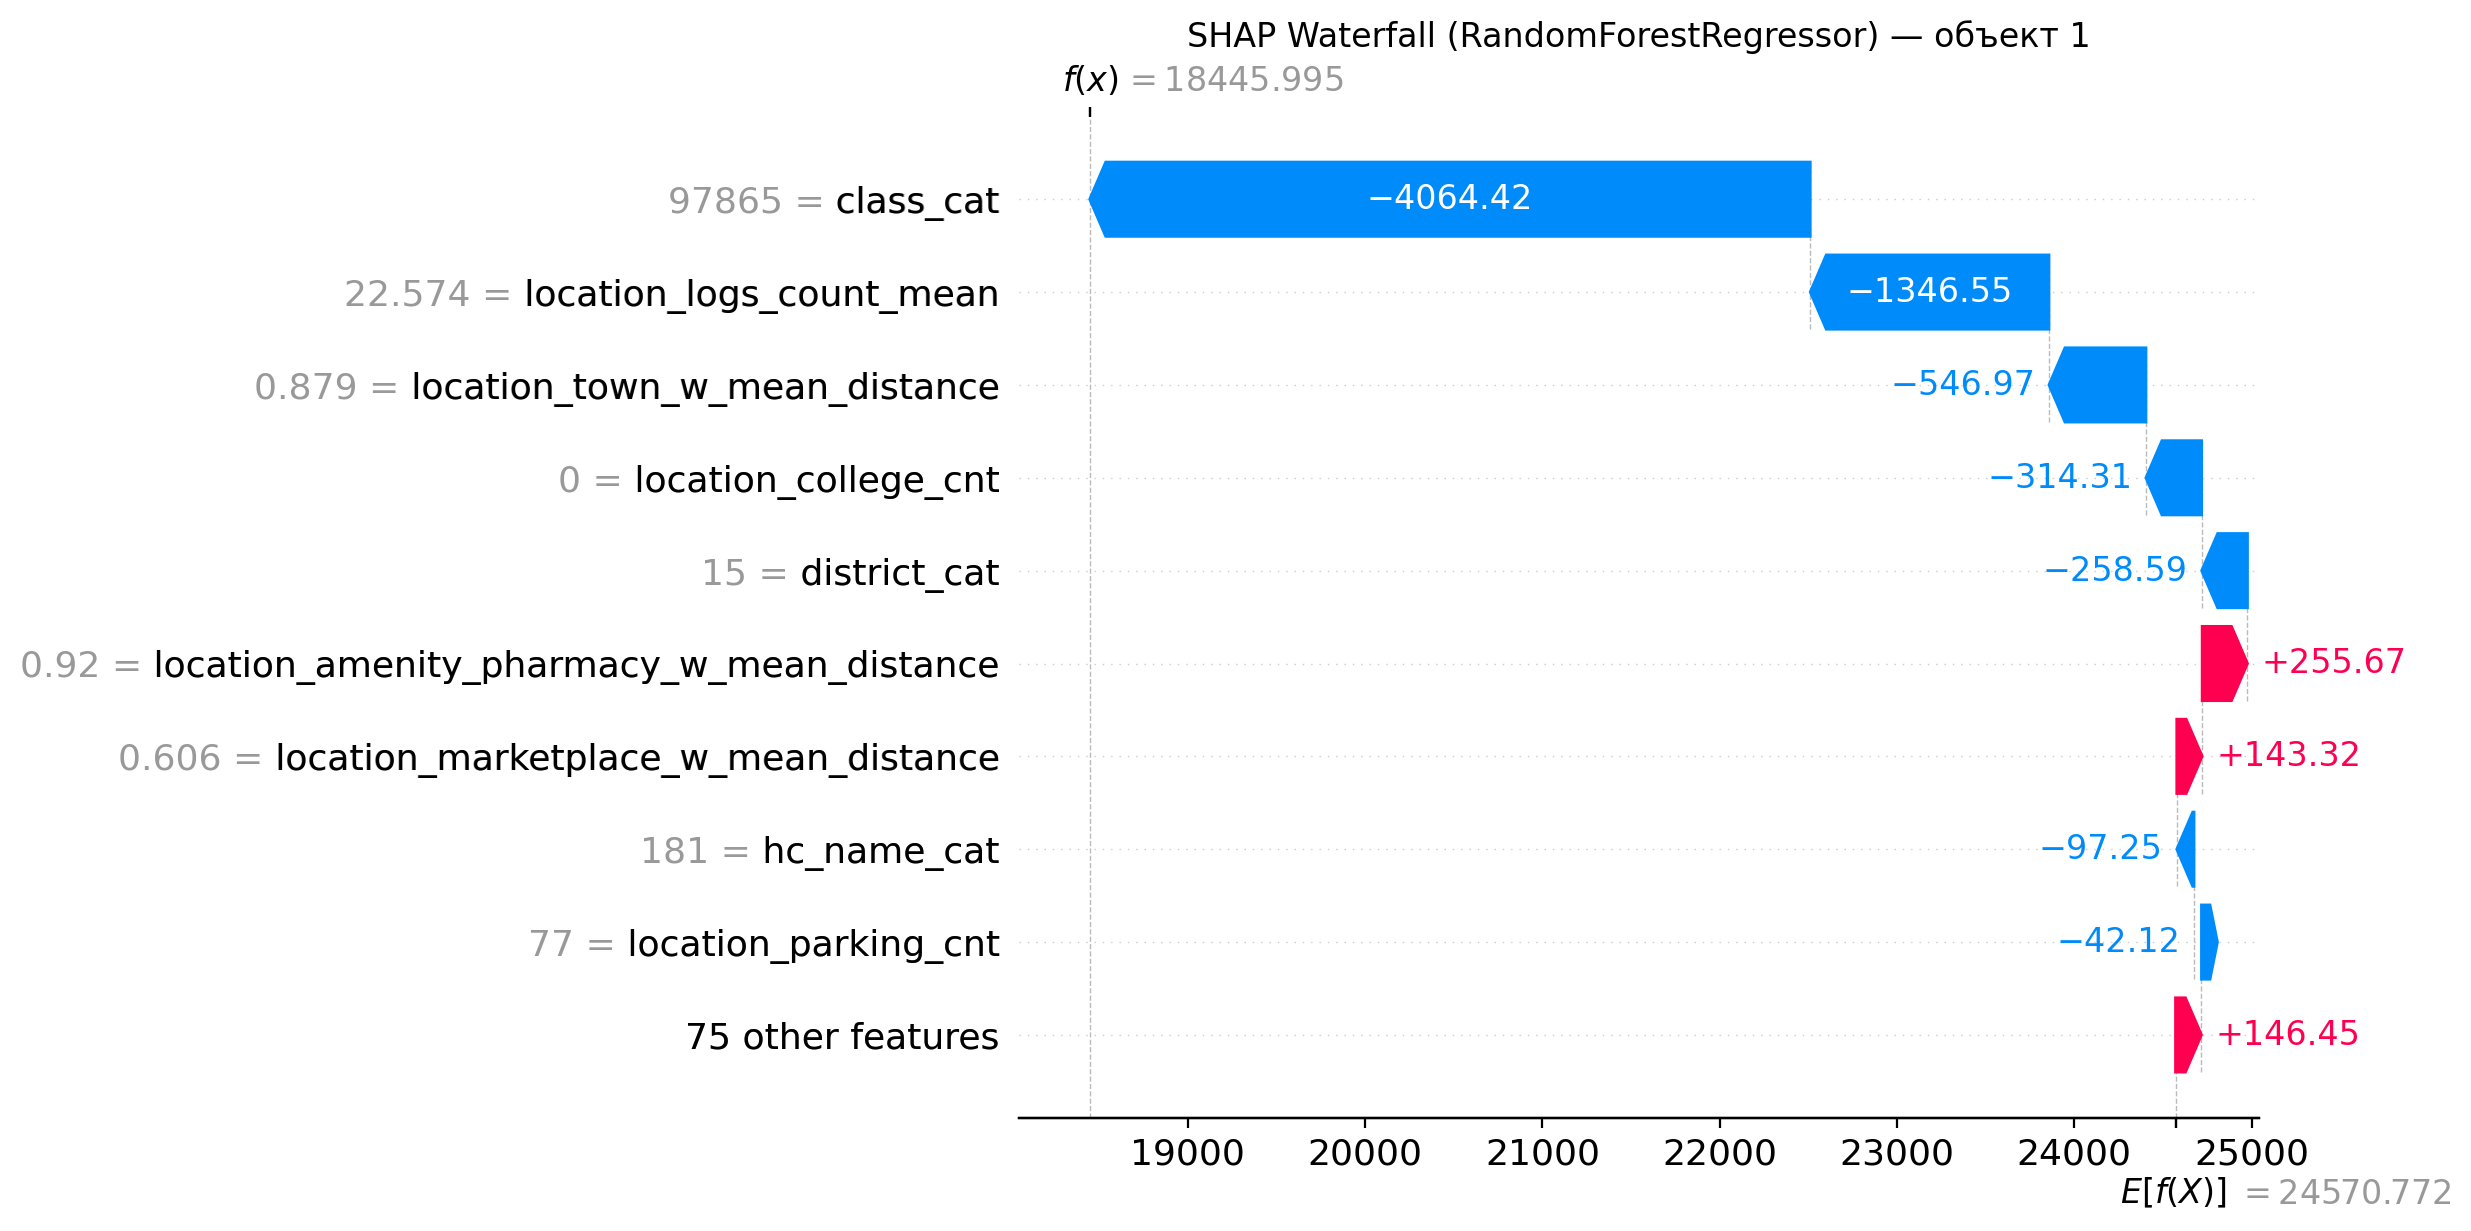

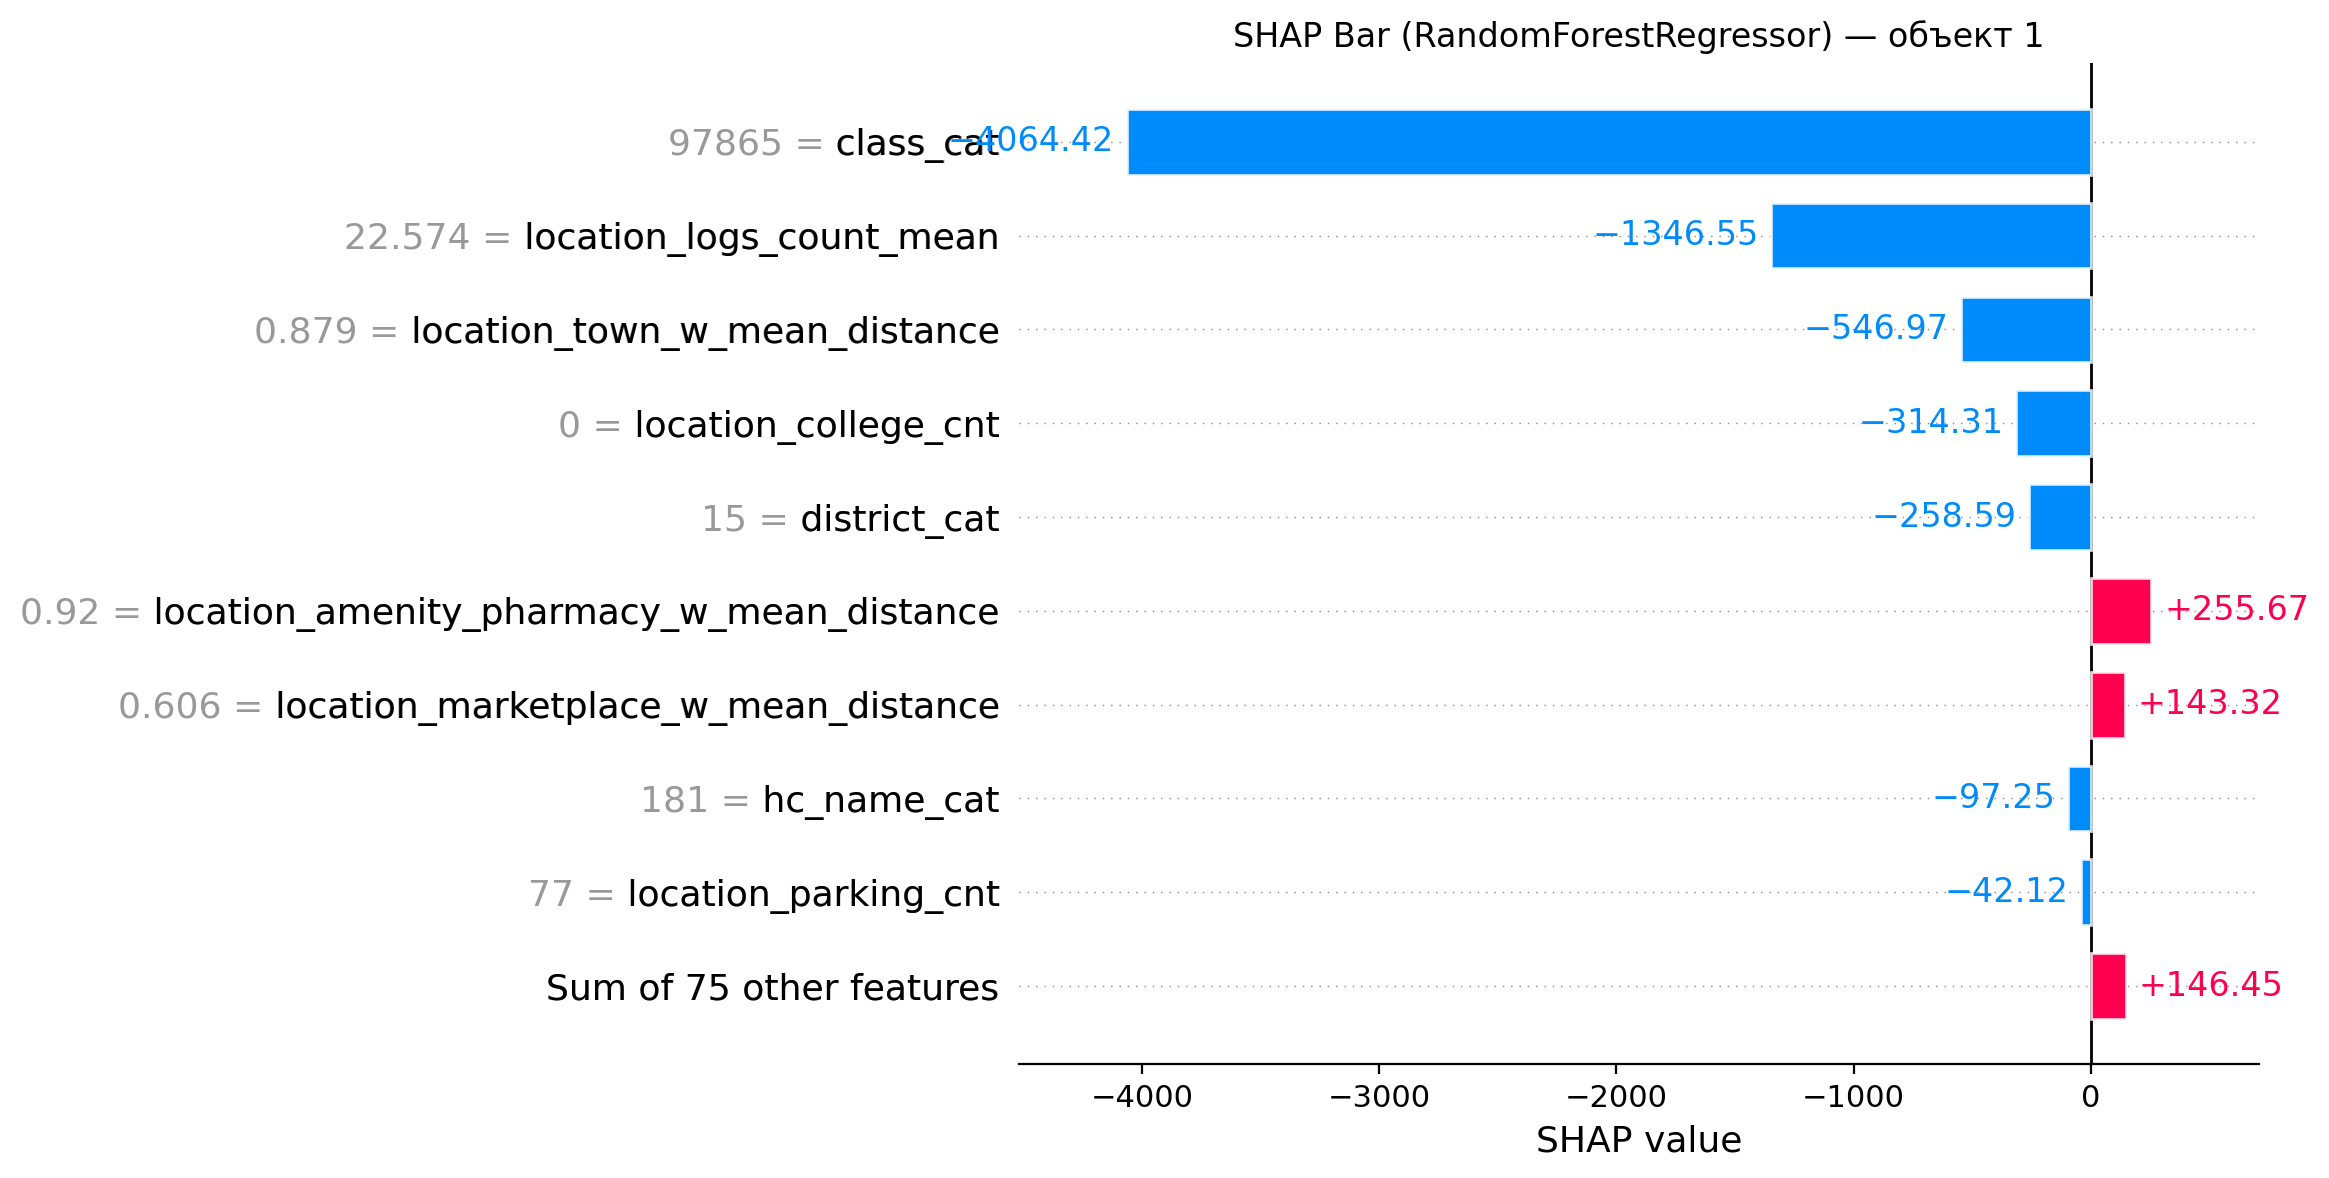

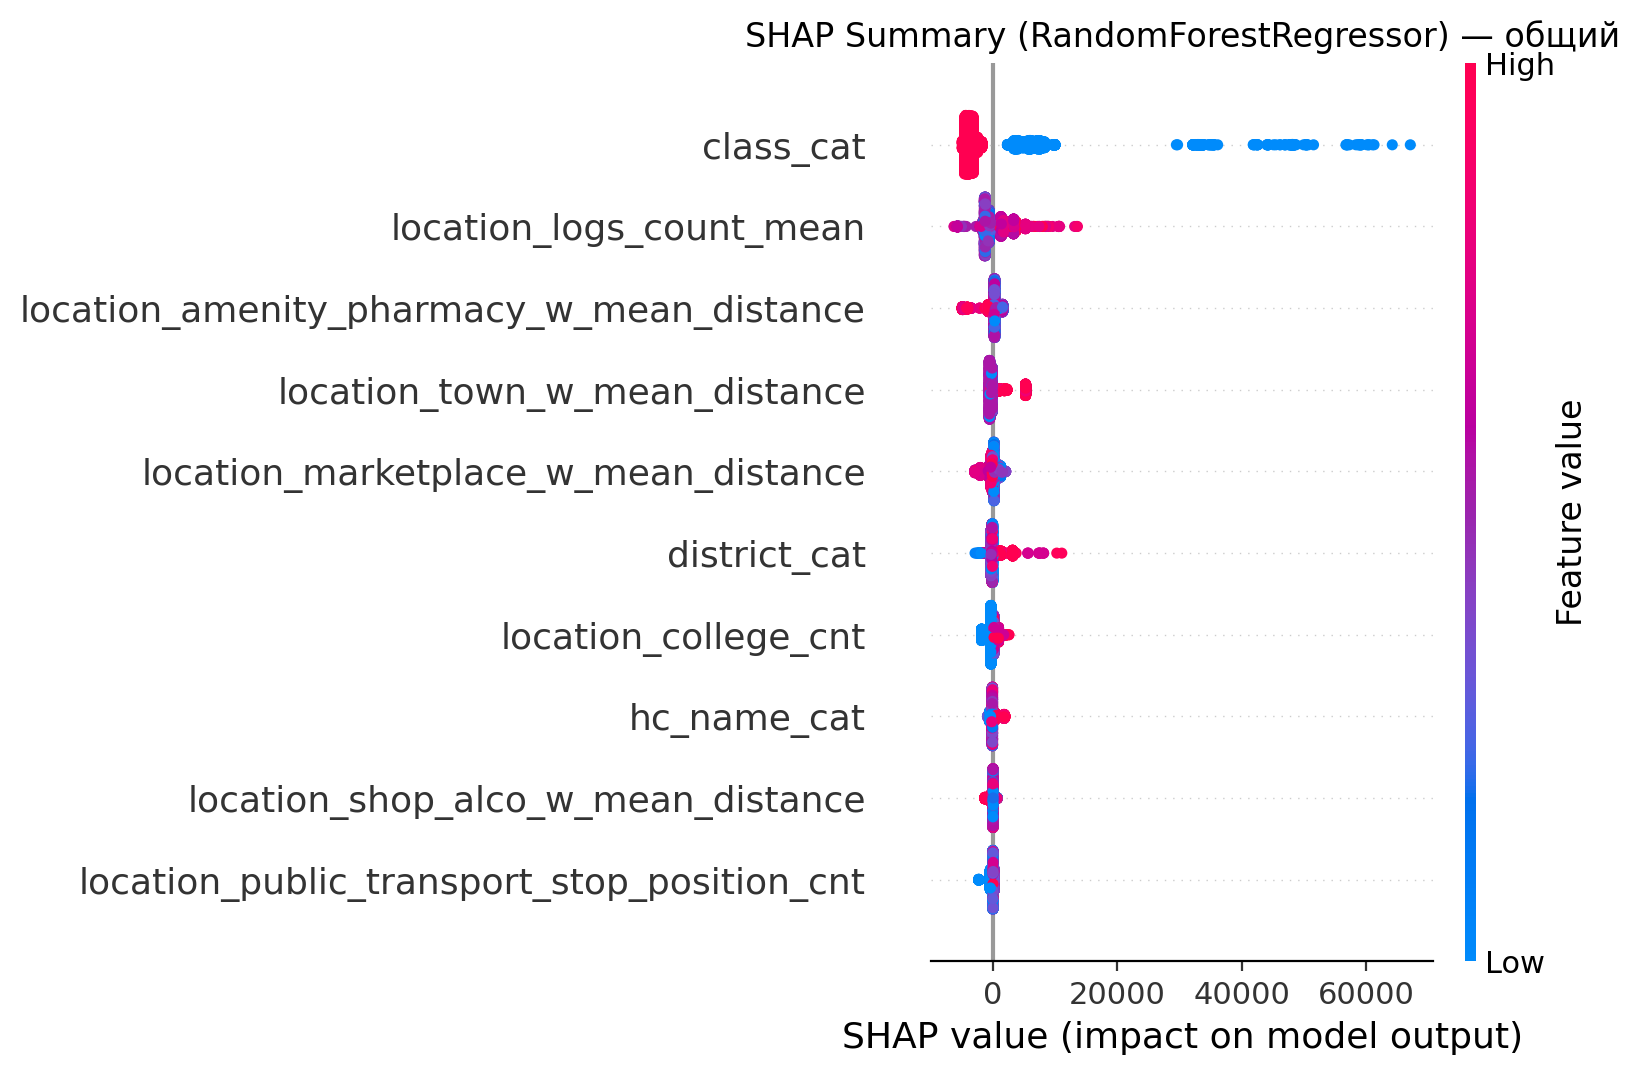

In [94]:
models_raw['RF_raw'] = RandomForestRegressor(max_depth=5, random_state=42)
models_raw['RF_raw'].fit(X_train, y_train)

explainer_lr = shap.TreeExplainer(models_raw['RF_raw'])
shap_values_lr = explainer_lr(X_test)

plt.title(f"SHAP Waterfall (RandomForestRegressor) — объект {student_index}")
shap.plots.waterfall(shap_values_lr[student_index], max_display=10)

plt.title(f"SHAP Bar (RandomForestRegressor) — объект {student_index}")
shap.plots.bar(shap_values_lr[student_index], max_display=10)

plt.title(f"SHAP Summary (RandomForestRegressor) — общий")
shap.summary_plot(shap_values_lr, X_test, max_display=10)

### GradientBoosting

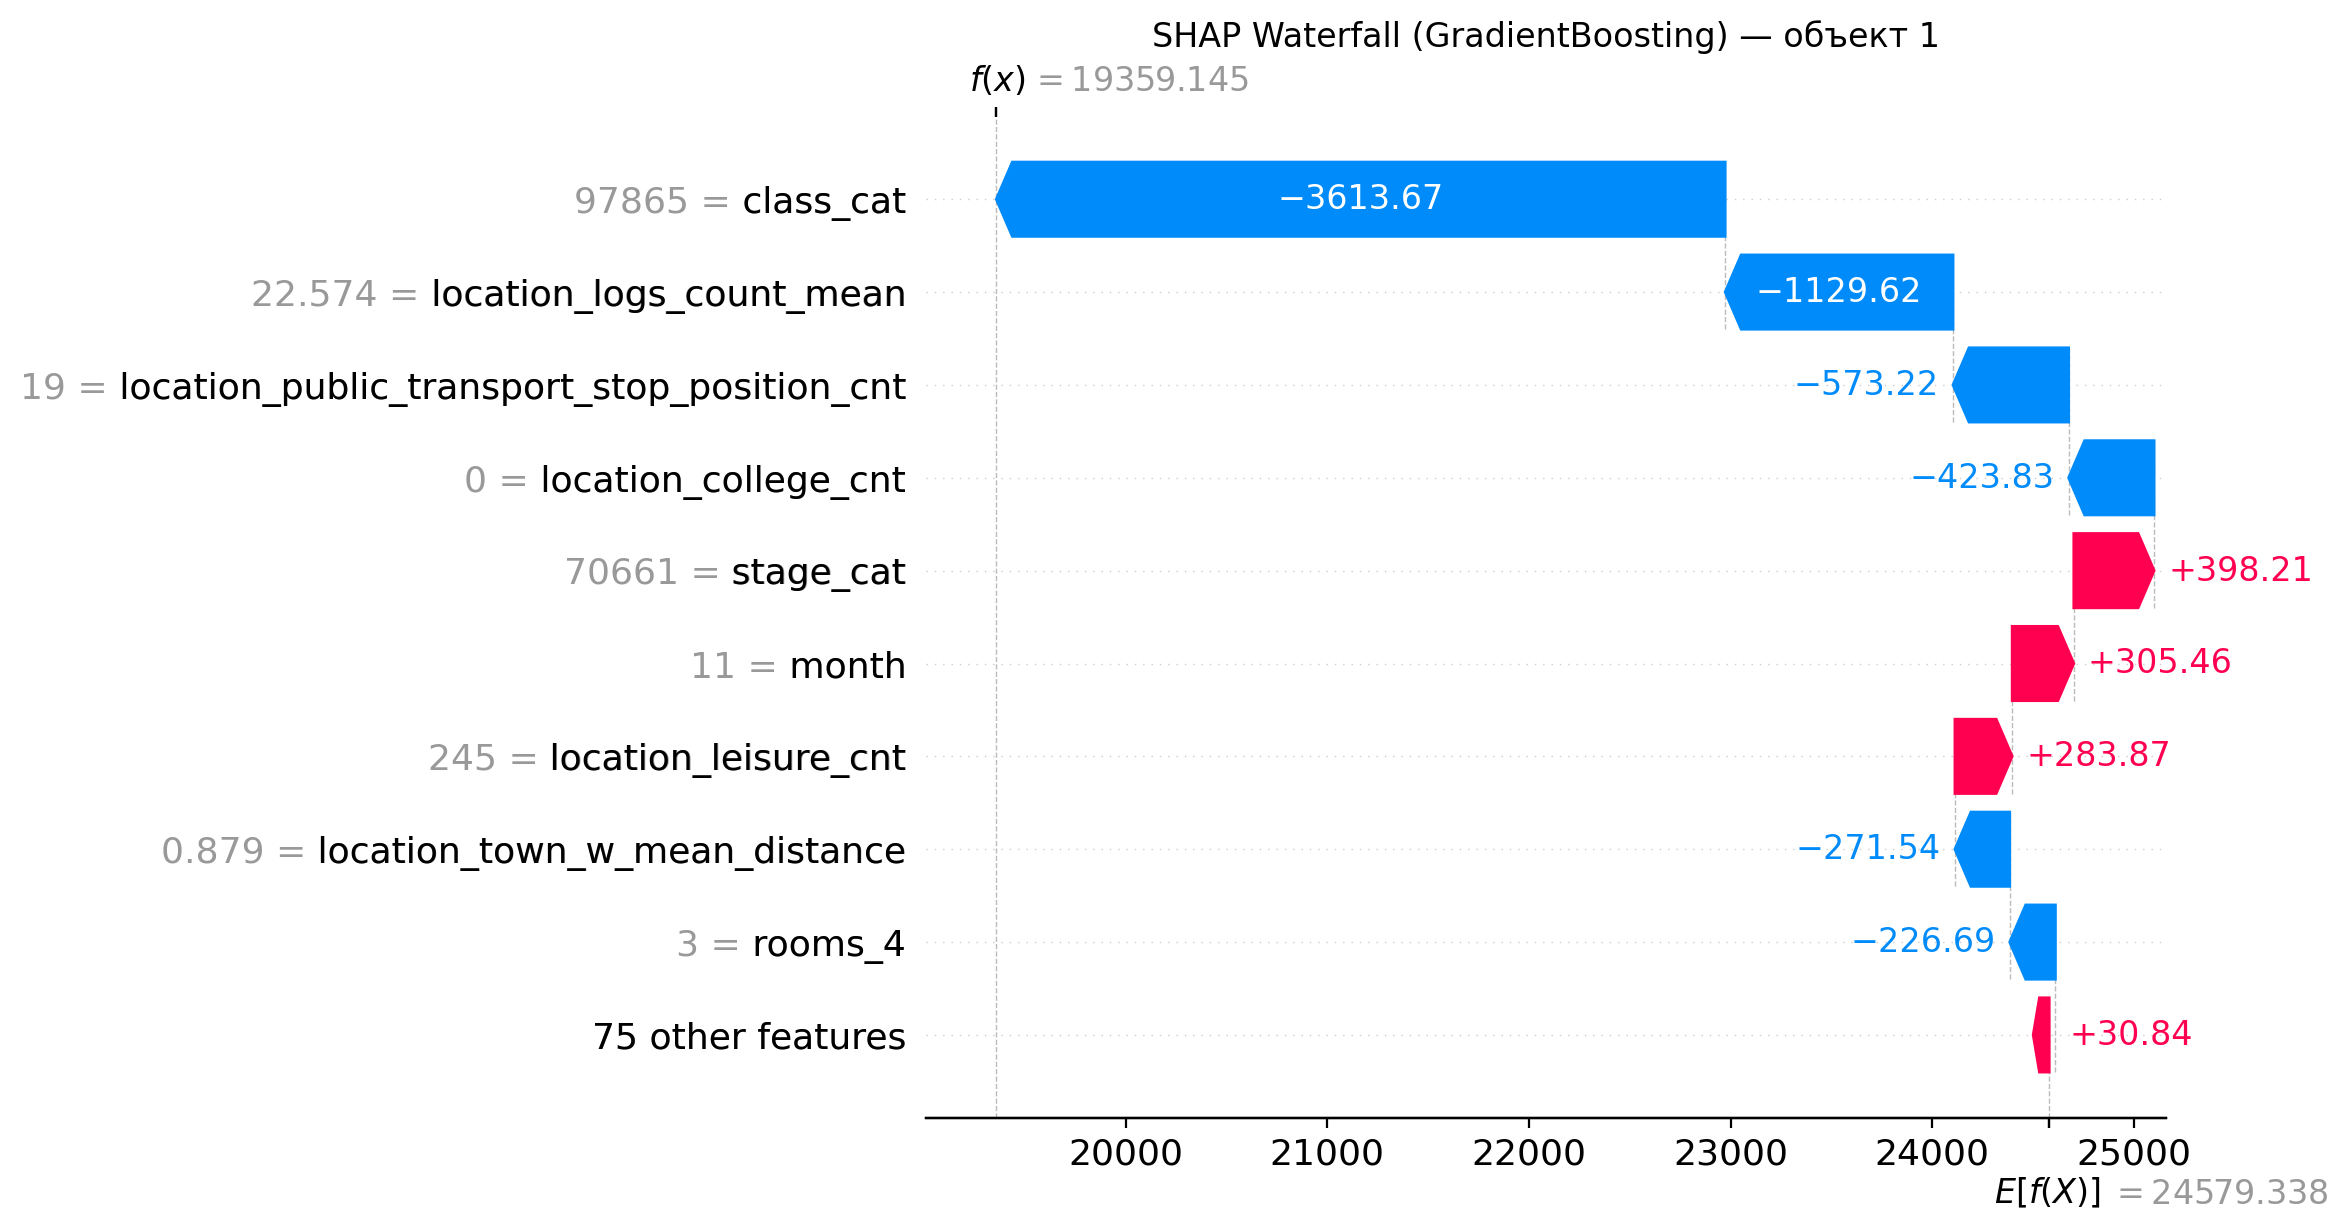

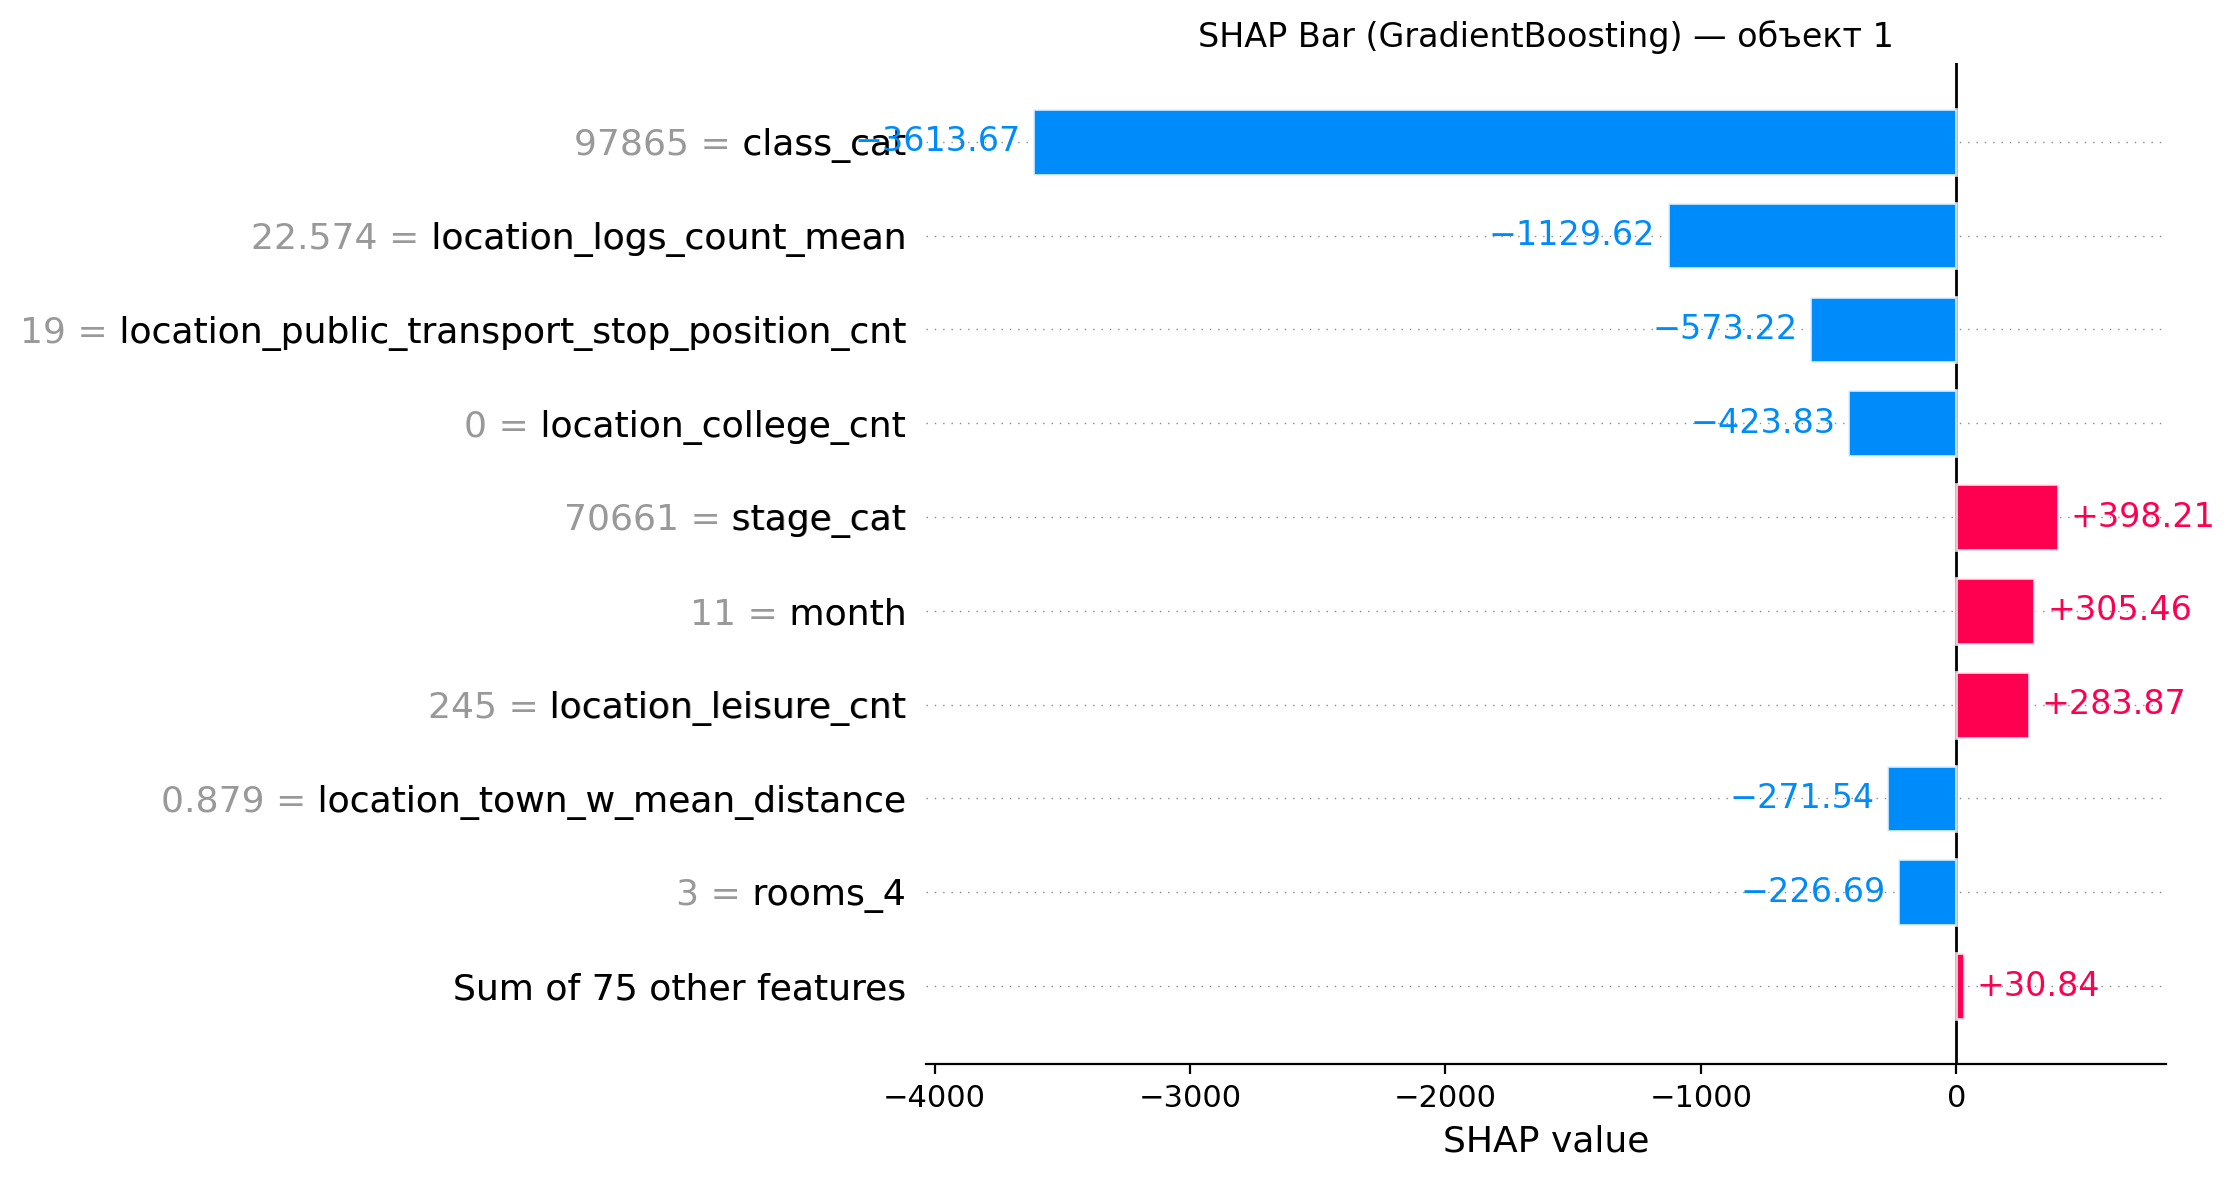

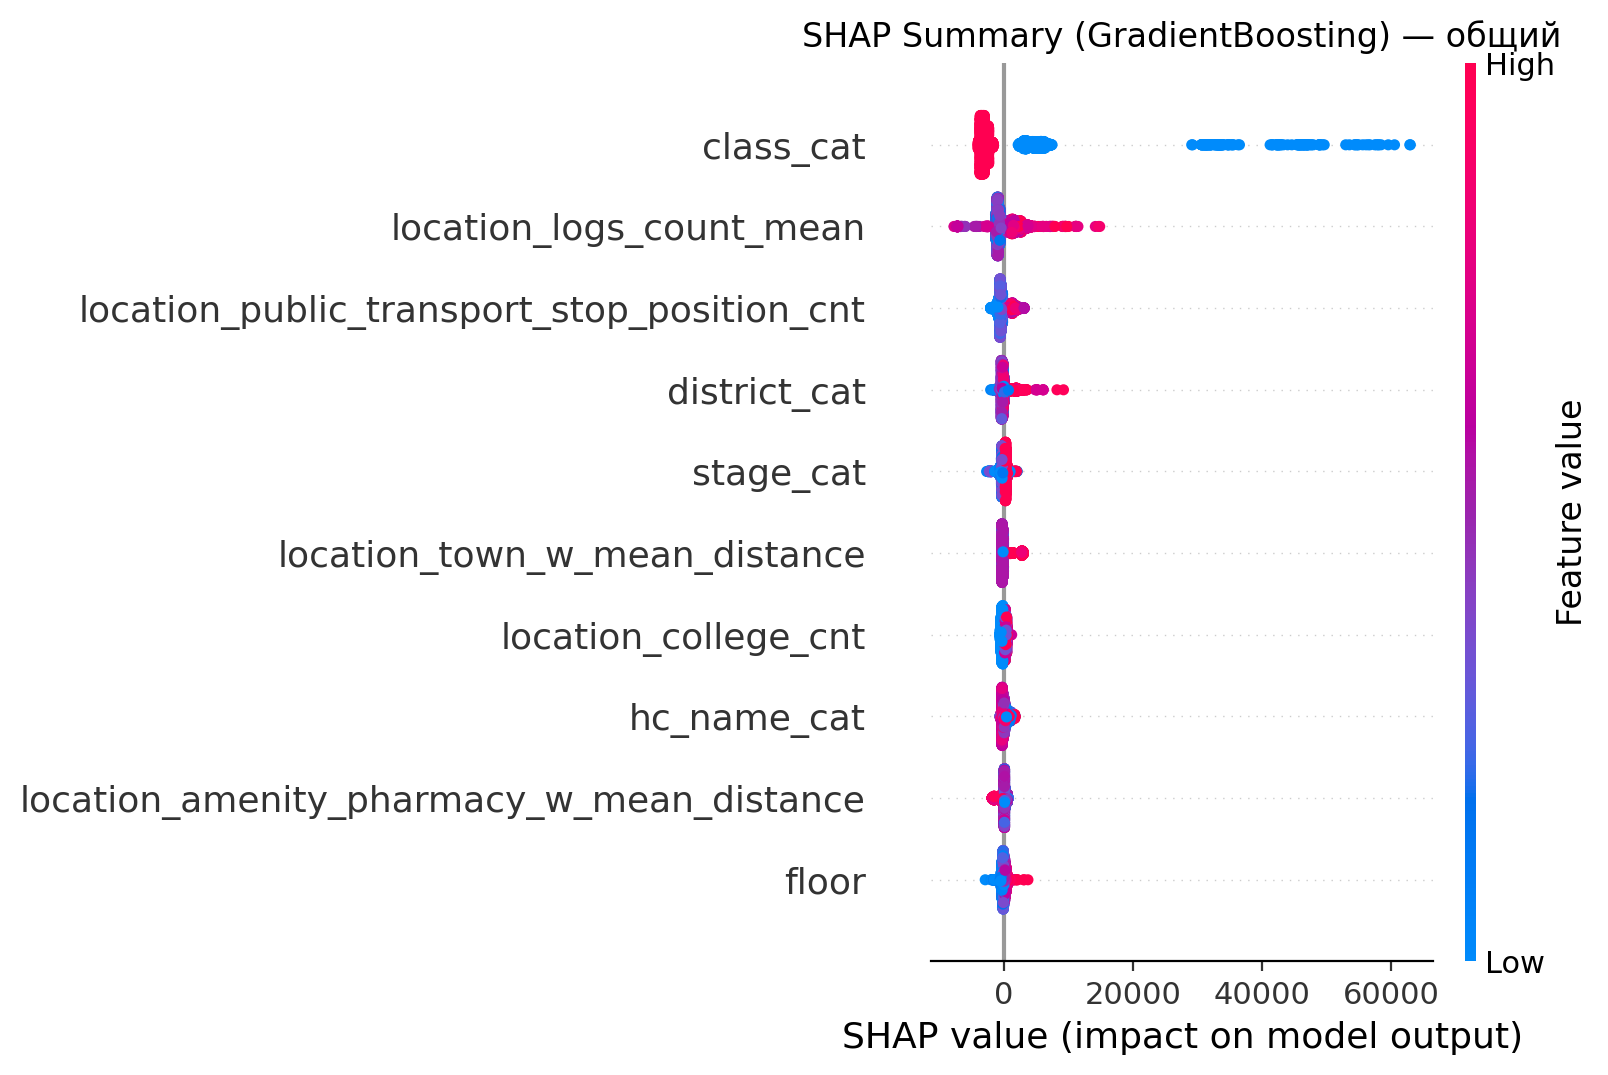

In [80]:
explainer_gb = shap.TreeExplainer(models_raw['GB_raw'])
shap_values_gb = explainer_gb(X_test)

plt.title(f"SHAP Waterfall (GradientBoosting) — объект {student_index}")
shap.plots.waterfall(shap_values_gb[student_index], max_display=10)

plt.title(f"SHAP Bar (GradientBoosting) — объект {student_index}")
shap.plots.bar(shap_values_gb[student_index], max_display=10)

plt.title(f"SHAP Summary (GradientBoosting) — общий")
shap.summary_plot(shap_values_lr, X_test, max_display=10)

### Сравнение категориальных признаков

In [86]:
cat_cols = [col for col in X.columns if col.endswith('_cat')]

# Исходная модель (категории как числа)
print("Исходный вклад class_cat:", shap_values_gb.values[student_index][X_test.columns.get_loc('class_cat')])

Исходный вклад class_cat: -3613.673186137706


In [87]:
# One-hot кодирование + новая модель
preprocessor = ColumnTransformer([
    ('num', 'passthrough', [c for c in X.columns if c not in cat_cols]),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
])

pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=300, max_depth=5, random_state=42))
])

X_train_ohe = pipeline.named_steps['prep'].fit_transform(X_train)
X_test_ohe  = pipeline.named_steps['prep'].transform(X_test)

model_ohe = pipeline.named_steps['model']
model_ohe.fit(X_train_ohe, y_train)

explainer_ohe = shap.TreeExplainer(model_ohe)
shap_values_ohe = explainer_ohe.shap_values(X_test_ohe)

ohe_feature_names = (pipeline.named_steps['prep']
                     .named_transformers_['cat']
                     .get_feature_names_out(cat_cols))

all_feature_names = list(pipeline.named_steps['prep'].get_feature_names_out())

class_cat_dummies = [
    i for i, feature_name in enumerate(all_feature_names)
    if "class_cat_" in feature_name
]

sum_shap_class_cat_ohe = shap_values_ohe[student_index][class_cat_dummies].sum()

print(f"Сумма SHAP по всем dummy class_cat (one-hot): {sum_shap_class_cat_ohe:.2f}")
print(f"Сравнение: исходный (numeric) = {shap_values_gb.values[student_index][X_test.columns.get_loc('class_cat')]:.2f} | "
      f"one-hot сумма = {sum_shap_class_cat_ohe:.2f}")

Сумма SHAP по всем dummy class_cat (one-hot): -3667.78
Сравнение: исходный (numeric) = -3613.67 | one-hot сумма = -3667.78


**Вывод по 7:**

**Общие результаты предсказания**  
Для выбранного объекта модели выдали следующие прогнозы цены:  
- **GradientBoostingRegressor**: **19 359.15 руб.**  
- **RandomForestRegressor**: **18 445.995 руб.**  

Базовый уровень (среднее предсказание по всему датасету) в обеих моделях находится около **24 570–24 580 руб.**

**Самый сильный негативный фактор в обеих моделях — `class_cat = 97865`**:
- GradientBoosting: **−3 613.67 руб.**  
- RandomForest: **−4 064.42 руб.**  

Это самый большой «штраф» для цены объекта.

**Второй по силе негативный фактор — `location_logs_count_mean = 22.574`**:
- GradientBoosting: **−1 129.62 руб.**  
- RandomForest: **−1 346.55 руб.**

**Другие значимые вклады**:

**GradientBoosting**:
- Отрицательные: `location_public_transport_stop_position_cnt = 19` (−573), `location_college_cnt = 0` (−424), `location_town_w_mean_distance = 0.879` (−272), `rooms_4 = 3` (-227)
- Положительные: `stage_cat = 70661` (+398), `month = 11` (+305), `location_leisure_cnt = 245` (+284)

**RandomForest**:
- Отрицательные: `location_town_w_mean_distance` (−547), `location_college_cnt` (−314), `district_cat = 15` (−259)
- Положительные: `location_amenity_pharmacy_w_mean_distance` (+256), `location_marketplace_w_mean_distance` (+143)

**Сравнение моделей**  
- Обе модели **полностью согласны** в главных факторах снижения цены: класс жилья и высокое значение `location_logs_count_mean`.
- GradientBoosting сильнее реагирует на стадию готовности (`stage_cat`) и месяц продажи.
- RandomForest больше учитывает локационные особенности (расстояние до города, аптек, рынков).

**SHAP и категориальные признаки**  
Сравнили вклад признака `class_cat` до и после one-hot кодирования:

- При числовом кодировании: **−3 613.67**
- После one-hot (сумма всех dummy-переменных): **−3 667.78**

**Разница всего 54 рубля (~1.5%)** — практически идентичные значения.

**Вывод**: SHAP корректно агрегирует вклад категориального признака. Даже если в основной модели категории закодированы как числа, SHAP правильно понимает их влияние (как и заявлено в теории: сумма по dummy-столбцам = вклад всей категории).